<a href="https://colab.research.google.com/github/Shr06/d2c_churn_part1_eda/blob/main/eda_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Data Audit, EDA & Business Understanding

## Objective

Before building any churn prediction model or retention strategy, the objective of this analysis is to:

- Audit all raw datasets
- Validate data quality
- Verify joins and data consistency
- Prevent data leakage
- Explore customer behaviour
- Identify churn-risk patterns
- Generate business hypotheses for retention

## Setup Instructions

This notebook is developed in Google Colab.

**To run this notebook:**
- If running in **Google Colab**: Mount your drive and update `BASE_PATH` to your dataset location
- If running **locally**: Comment out the `drive.mount()` cell and update `BASE_PATH` to your local dataset path


In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None) # shows all columns in table
sns.set_style('whitegrid') # helps graph look clean
plt.rcParams['figure.figsize'] = (10,6) # default size for graph

In [67]:
# Adding path and check
BASE_PATH = "/content/drive/MyDrive/d2c_churn/data/"
print("Files available:", os.listdir(BASE_PATH))

Files available: ['churn_labels.csv', 'customers.csv', 'intervention_history.csv', 'orders.csv', 'rfm_modeling_snapshot.csv', 'support_tickets.csv', 'web_events_snapshot.csv']


In [68]:
#Loading Datasets
customers = pd.read_csv(BASE_PATH + 'customers.csv')
orders = pd.read_csv(BASE_PATH + 'orders.csv')
support_tickets = pd.read_csv(BASE_PATH + 'support_tickets.csv')
web_events = pd.read_csv(BASE_PATH + 'web_events_snapshot.csv')
churn_labels = pd.read_csv(BASE_PATH + 'churn_labels.csv')
rfm_snapshot = pd.read_csv(BASE_PATH + 'rfm_modeling_snapshot.csv')
intervention_history = pd.read_csv(BASE_PATH + 'intervention_history.csv')

In [69]:
#DATASET INVENTORY
inventory_table = pd.DataFrame({
'Dataset': ['customers','orders','support_tickets','web_events_snapshot',
        'churn_labels','rfm_modeling_snapshot','intervention_history'],
'Rows': [customers.shape[0],orders.shape[0],support_tickets.shape[0],
        web_events.shape[0],churn_labels.shape[0],rfm_snapshot.shape[0],
        intervention_history.shape[0]],
'Columns':[customers.shape[1],orders.shape[1],support_tickets.shape[1],
        web_events.shape[1],churn_labels.shape[1],rfm_snapshot.shape[1],
        intervention_history.shape[1]],
'Grain':['One row per customer','One row per order line','One row per support ticket',
        'One row per customer','One row per customer',
        'One row per customer','One row per customer']})
inventory_table

,Dataset,Rows,Columns,Grain
0,customers,2400,9,One row per customer
1,orders,10009,10,One row per order line
2,support_tickets,1921,8,One row per support ticket
3,web_events_snapshot,2400,10,One row per customer
4,churn_labels,2400,4,One row per customer
5,rfm_modeling_snapshot,2400,29,One row per customer
6,intervention_history,2400,5,One row per customer


#DATA SUMMARY (RAW DATA)

In [70]:
#Creating dataset summary function
def dataset_summary(df, name):
  print('\n' + '='*40)
  print(name.upper())
  print('='*40)
  print('\nShape:',df.shape)
  print('\nColumns:',df.columns.tolist())
  print(f'\nData Types:\n',df.dtypes)
  print('\nMissing Values:\n',df.isnull().sum())
  print('\nDuplicate Rows:',df.duplicated().sum())
  print(f"\nMemory Usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")
  print(f"\nNumeric Columns: {len(df.select_dtypes(include='number').columns)}")
  print(f"Categorical Columns: {len(df.select_dtypes(include='object').columns)}")
  print(f"Datetime Columns: {len(df.select_dtypes(include='datetime').columns)}")
  print("\nUnique Values Per Column:\n",df.nunique())
  print('\nSample Data:',df.head(3))

In [71]:
#Summary of customers.csv file
dataset_summary(customers, 'customers')


CUSTOMERS

Shape: (2400, 9)

Columns: ['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']

Data Types:
 customer_id            object
signup_date            object
city_tier              object
age_group              object
acquisition_channel    object
loyalty_tier           object
preferred_category     object
skin_type              object
marketing_consent      object
dtype: object

Missing Values:
 customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

Duplicate Rows: 0

Memory Usage: 1.11 MB

Numeric Columns: 0
Categorical Columns: 9
Datetime Columns: 0

Unique Values Per Column:
 customer_id            2400
signup_date             609
city_tier                 3
age_group  

In [72]:
#Summary of orders.csv file
dataset_summary(orders, 'orders')


ORDERS

Shape: (10009, 10)

Columns: ['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']

Data Types:
 order_id          object
customer_id       object
order_date        object
category          object
quantity           int64
gross_amount     float64
discount_pct     float64
delivery_days      int64
returned           int64
rating           float64
dtype: object

Missing Values:
 order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

Duplicate Rows: 0

Memory Usage: 2.68 MB

Numeric Columns: 6
Categorical Columns: 4
Datetime Columns: 0

Unique Values Per Column:
 order_id         10009
customer_id       2400
order_date         674
category             6
quantity             4
gross_amount      9514
discount_pct        71
delivery_days       11

In [73]:
#Summary of support_tickets.csv file
dataset_summary(support_tickets, 'support_tickets')


SUPPORT_TICKETS

Shape: (1921, 8)

Columns: ['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']

Data Types:
 ticket_id            object
customer_id          object
ticket_date          object
issue_type           object
support_channel      object
resolution_hours    float64
sentiment_score     float64
reopened              int64
dtype: object

Missing Values:
 ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

Duplicate Rows: 0

Memory Usage: 0.58 MB

Numeric Columns: 3
Categorical Columns: 5
Datetime Columns: 0

Unique Values Per Column:
 ticket_id           1921
customer_id         1247
ticket_date          526
issue_type             7
support_channel        3
resolution_hours     525
sentiment_score      181
reopened               2
dtype: int64

Sample Data:    ticke

In [74]:
#Summary of web_events_snapshot.csv file
dataset_summary(web_events, 'web_events')


WEB_EVENTS

Shape: (2400, 10)

Columns: ['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']

Data Types:
 customer_id            object
snapshot_date          object
sessions_30d            int64
product_views_30d       int64
cart_adds_30d           int64
wishlist_adds_30d       int64
abandoned_carts_30d     int64
email_opens_30d         int64
campaign_clicks_30d     int64
last_visit_days_ago     int64
dtype: object

Missing Values:
 customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64

Duplicate Rows: 0

Memory Usage: 0.41 MB

Numeric Columns: 8
Categorical Columns: 2
Datetime Columns: 0

Unique Values Per Column:
 customer_id          

In [75]:
#Summary of churn_labels.csv file
dataset_summary(churn_labels, 'churn_labels')


CHURN_LABELS

Shape: (2400, 4)

Columns: ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']

Data Types:
 customer_id       object
snapshot_date     object
churn_next_60d     int64
split             object
dtype: object

Missing Values:
 customer_id       0
snapshot_date     0
churn_next_60d    0
split             0
dtype: int64

Duplicate Rows: 0

Memory Usage: 0.41 MB

Numeric Columns: 1
Categorical Columns: 3
Datetime Columns: 0

Unique Values Per Column:
 customer_id       2400
snapshot_date        1
churn_next_60d       2
split                3
dtype: int64

Sample Data:   customer_id snapshot_date  churn_next_60d  split
0   CUST00001    2025-09-30               1  train
1   CUST00002    2025-09-30               0  train
2   CUST00003    2025-09-30               1  train


In [76]:
#Summary of rfm_modeling_snapshot.csv file
dataset_summary(rfm_snapshot, 'rfm_snapshot')


RFM_SNAPSHOT

Shape: (2400, 29)

Columns: ['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Data Types:
 customer_id                  object
snapshot_date                object
city_tier                    object
age_group                    object
acquisition_channel          object
loyalty_tier                 object
preferred_category           object
marketing_consent            object
recency_days                  int64
frequency_180d                int64
monetary_180d

In [77]:
#Summary of intervention_history.csv file
dataset_summary(intervention_history, 'intervention_history')


INTERVENTION_HISTORY

Shape: (2400, 5)

Columns: ['customer_id', 'snapshot_date', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']

Data Types:
 customer_id               object
snapshot_date             object
last_campaign_received    object
last_campaign_cost         int64
manual_priority_bucket    object
dtype: object

Missing Values:
 customer_id               0
snapshot_date             0
last_campaign_received    0
last_campaign_cost        0
manual_priority_bucket    0
dtype: int64

Duplicate Rows: 0

Memory Usage: 0.55 MB

Numeric Columns: 1
Categorical Columns: 4
Datetime Columns: 0

Unique Values Per Column:
 customer_id               2400
snapshot_date                1
last_campaign_received       5
last_campaign_cost           5
manual_priority_bucket       3
dtype: int64

Sample Data:   customer_id snapshot_date last_campaign_received  last_campaign_cost  \
0   CUST00001    2025-09-30          welcome_offer                  25   
1   CUST00002   

#Data Type Corrections

In [78]:
#Value conversion to datatime
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

orders['order_date'] = pd.to_datetime(orders['order_date'])

support_tickets['ticket_date'] = pd.to_datetime(support_tickets['ticket_date'])

web_events['snapshot_date'] = pd.to_datetime(web_events['snapshot_date'])

churn_labels['snapshot_date'] = pd.to_datetime(churn_labels['snapshot_date'])

rfm_snapshot['snapshot_date'] = pd.to_datetime(rfm_snapshot['snapshot_date'])

intervention_history['snapshot_date'] = pd.to_datetime(intervention_history['snapshot_date'])
#verifying
print(customers['signup_date'].dtype)
print(orders['order_date'].dtype)

datetime64[ns]
datetime64[ns]


##Relationship Overview

* The common key across all datasets is **customer_id**.

* The customers dataset contains information for all 2,400 customers.

* Thus will be used as the main(primary) table for joining other datasets.

* Other datasets such as orders, support tickets, web activity, churn labels, and intervention history can be linked using customer_id(common key).




In [79]:
# Join Validation - Customer Coverage
#Verifying customer_id is available and consistent across all files.
print("="*50)
print("JOIN  VALIDATION")
print("="*50)

customer_counts = {
    "Customers": customers['customer_id'].nunique(),
    "Orders": orders['customer_id'].nunique(),
    "Support Tickets": support_tickets['customer_id'].nunique(),
    "Web Events": web_events['customer_id'].nunique(),
    "Churn Labels": churn_labels['customer_id'].nunique(),
    "Intervention History": intervention_history['customer_id'].nunique()}
for dataset, count in customer_counts.items():
  print(f"{dataset:<25}: {count:,} unique customers")
print("\nCustomer ID Match Check")
print("-"*50)
print("Orders not found in Customers:",(~orders['customer_id'].isin(customers['customer_id'])).sum())
print("Support Tickets not found in Customers:",(~support_tickets['customer_id'].isin(customers['customer_id'])).sum())
print("Web Events not found in Customers:",(~web_events['customer_id'].isin(customers['customer_id'])).sum())
print("Churn Labels not found in Customers:",(~churn_labels['customer_id'].isin(customers['customer_id'])).sum())
print("Intervention History not found in Customers:",(~intervention_history['customer_id'].isin(customers['customer_id'])).sum())

JOIN  VALIDATION
Customers                : 2,400 unique customers
Orders                   : 2,400 unique customers
Support Tickets          : 1,247 unique customers
Web Events               : 2,400 unique customers
Churn Labels             : 2,400 unique customers
Intervention History     : 2,400 unique customers

Customer ID Match Check
--------------------------------------------------
Orders not found in Customers: 0
Support Tickets not found in Customers: 0
Web Events not found in Customers: 0
Churn Labels not found in Customers: 0
Intervention History not found in Customers: 0


## **Leakage Check**

### What is Data Leakage?

  * It happens when information from the future is accidentally used for analysis or training a model.
  * This gives the model access to information that would not be available at the time of prediction.

---

### Why Are We Checking for Leakage?
 * To understand customer behaviour as it existed on or before the snapshot date **2025-09-30**. Thus predict future churn and prevent unrealistically high performance and incorrect business decisions.

---

### Approach Used

* To prevent leakage, the orders dataset was divided into:

**Pre-snapshot orders**

    order_date <= 2025-09-30

 **Post-snapshot orders**

    order_date > 2025-09-30

* Only pre-snapshot orders will be considered valid for analysis and future feature creation.

* The post-snapshot orders are kept separate because they represent customer activity that occurred after the reference date.

---

### **Benefits of Preventing Leakage**

By removing post-snapshot information the results will be more realistic, reproducible, and useful for business decision-making.

In [80]:
#Leakage control
SNAPSHOT_DATE = pd.to_datetime('2025-09-30')
pre_snapshot_orders = orders[orders['order_date'] <= SNAPSHOT_DATE].copy()
post_snapshot_orders = orders[orders['order_date'] > SNAPSHOT_DATE].copy()

print('Total Orders      :', len(orders))
print('Pre-Snapshot Orders :', len(pre_snapshot_orders))
print('Post-Snapshot Orders:', len(post_snapshot_orders))

#Hard assertion — if this fails, we have leakage
assert post_snapshot_orders['order_date'].max() > SNAPSHOT_DATE, "Post-snapshot filter failed"
assert pre_snapshot_orders['order_date'].max() <= SNAPSHOT_DATE, "Leakage detected in pre_snapshot_orders!"
print("\nLeakage check passed. Only pre-snapshot orders will be used as features.")

Total Orders      : 10009
Pre-Snapshot Orders : 8137
Post-Snapshot Orders: 1872

Leakage check passed. Only pre-snapshot orders will be used as features.


In [81]:
#LEAKAGE COLUMN INVENTORY
#columns that must never be used as features

leakage_inventory = pd.DataFrame([
    {
        'dataset': 'churn_labels',
        'column': 'churn_next_60d',
        'leakage_type': 'Direct target leakage',
        'reason': 'This is the target variable, using it as a feature causes perfect but meaningless predictions.'
    },
    {
        'dataset': 'churn_labels',
        'column': 'split',
        'leakage_type': 'Data split leakage',
        'reason': 'This encodes train/test assignment,thus must never enter the feature matrix.'
    },
    {
        'dataset': 'intervention_history',
        'column': 'last_campaign_received',
        'leakage_type': 'Post-decision leakage',
        'reason': 'The campaign encodes future knowledge, as it may have been triggered by a prior churn prediction.'
    },
    {
        'dataset': 'intervention_history',
        'column': 'manual_priority_bucket',
        'leakage_type': 'Post-decision leakage',
        'reason': 'Priority assigned by a human/model that already knew churn risk — encodes the outcome indirectly.'
    },
    {
        'dataset': 'intervention_history',
        'column': 'last_campaign_cost',
        'leakage_type': 'Post-decision leakage',
        'reason': 'Cost flows from campaign decisions made after churn risk was assessed — proxy for the label.'
    },
    {
        'dataset': 'orders',
        'column': 'order_date > 2025-09-30 (post-snapshot rows)',
        'leakage_type': 'Temporal leakage',
        'reason': 'Orders after the snapshot date reflect future behaviour unknown at prediction time.'
    },
    {
        'dataset': 'rfm_snapshot',
        'column': 'Any RFM field if recomputed on full orders',
        'leakage_type': 'Temporal leakage',
        'reason': 'RFM metrics must be computed only on pre-snapshot orders. Post-snapshot transactions must be excluded.'
    },
])

print("-" *75)
print("LEAKAGE COLUMN INVENTORY")
print("-" *75)
print(leakage_inventory.to_string(index=False))
LEAKAGE_COLUMNS = {
    'churn_labels':           ['churn_next_60d', 'split'],
    'intervention_history':   ['last_campaign_received', 'manual_priority_bucket', 'last_campaign_cost'],
    }

print("\n" + "-" * 75)
print("LEAKAGE COLUMN CHECK ACROSS ALL DATASETS")
print("-" * 75)
datasets = {
    'churn_labels': churn_labels,
    'intervention_history': intervention_history
}
for dataset_name, risky_cols in LEAKAGE_COLUMNS.items():
  df = datasets[dataset_name]
  print(f"\n{dataset_name.upper()}")
  print("-" * 75)
  for col in risky_cols:
    present = col in df.columns
    status  = "PRESENT — must be excluded before feature engineering" if present else "Not found (already excluded)"
    print(f" {col}: {status}")
#Verify the post-snapshot split is still clean
print("\n" + "-" *70)
print("POST-SNAPSHOT TEMPORAL LEAKAGE GUARD")
print("-" *75)

assert pre_snapshot_orders['order_date'].max() <= SNAPSHOT_DATE, \
    "LEAKAGE: pre_snapshot_orders contains rows after the snapshot date"
assert post_snapshot_orders['order_date'].min() > SNAPSHOT_DATE, \
    "LEAKAGE: post_snapshot_orders contains rows on or before the snapshot date"

print(f"pre_snapshot_orders max date : {pre_snapshot_orders['order_date'].max().date()}  <= {SNAPSHOT_DATE.date()}")
print(f"post_snapshot_orders min date: {post_snapshot_orders['order_date'].min().date()}  >  {SNAPSHOT_DATE.date()}")
print(f"\n  All temporal leakage guards passed.")

# Summary
print("\n" + "=" *75)
print("LEAKAGE AUDIT SUMMARY")
print("=" *75)
print(f"Total leakage-risk columns identified : {len(leakage_inventory)}")
print(f"Leakage types covered:")
for lt in leakage_inventory['leakage_type'].unique():
    count = (leakage_inventory['leakage_type'] == lt).sum()
    print(f"    • {lt} ({count} column{'s' if count > 1 else ''})")
print("\n RESULT: Drop or exclude all columns above before constructing the feature matrix.")

---------------------------------------------------------------------------
LEAKAGE COLUMN INVENTORY
---------------------------------------------------------------------------
             dataset                                       column          leakage_type                                                                                                 reason
        churn_labels                               churn_next_60d Direct target leakage         This is the target variable, using it as a feature causes perfect but meaningless predictions.
        churn_labels                                        split    Data split leakage                           This encodes train/test assignment,thus must never enter the feature matrix.
intervention_history                       last_campaign_received Post-decision leakage      The campaign encodes future knowledge, as it may have been triggered by a prior churn prediction.
intervention_history                       manual_priority_

#Data Quality report

In [82]:
#1.Missing values from all the files
print("=" * 50)
print("MISSING VALUE AUDIT ACROSS ALL DATASETS")
print("=" * 50)

datasets = {'customers': customers,'orders (pre-snapshot)': pre_snapshot_orders,
    'support_tickets': support_tickets,'web_events': web_events,
    'rfm_snapshot': rfm_snapshot,'intervention_history': intervention_history,
    'churn_labels': churn_labels}

for name, df in datasets.items():
  missing = df.isnull().sum()
  missing = missing[missing > 0]
  if len(missing) > 0:
    print(f"\n{name.upper()}")
    mv_df = pd.DataFrame({'Missing_Count': missing,
            'Missing_Pct': (missing / len(df) * 100).round(2)})
    print(mv_df.sort_values('Missing_Pct', ascending=False).to_string())
  else:
    print(f"\n {name.upper()} — No missing values")


MISSING VALUE AUDIT ACROSS ALL DATASETS

CUSTOMERS
              Missing_Count  Missing_Pct
loyalty_tier           1386        57.75
skin_type               401        16.71

ORDERS (PRE-SNAPSHOT)
        Missing_Count  Missing_Pct
rating             58         0.71

 SUPPORT_TICKETS — No missing values

 WEB_EVENTS — No missing values

RFM_SNAPSHOT
              Missing_Count  Missing_Pct
loyalty_tier           1386        57.75

 INTERVENTION_HISTORY — No missing values

 CHURN_LABELS — No missing values


In [83]:
#2.Duplicate Analysis
#Primary Key Duplicates
primary_keys = {
    'customers': 'customer_id',
    'orders (pre-snapshot)': 'order_id',
    'support_tickets': 'ticket_id',
    'web_events': 'customer_id',
    'churn_labels': 'customer_id',
    'rfm_snapshot': 'customer_id',
    'intervention_history': 'customer_id'}

for name, df in datasets.items():
  pk = primary_keys[name]
  print(f"\n{name.upper()}")
  print("-"*40)
  print("Total Rows:", len(df))
  print("Unique Primary key Values:", df[pk].nunique())
  print("Duplicate primary keys:", df[pk].duplicated().sum())

#Duplicate Order ID
dup_orders = orders[orders['order_id'].str.contains('_DUP', na=False)]
print(f"\nOrders with _DUP suffix: {len(dup_orders)}")
print(dup_orders[['order_id','customer_id','order_date','gross_amount']].head(10))

#Remove Duplicate-like Orders
orders_clean = orders[~orders['order_id'].str.contains('_DUP', na=False)].copy()
#Create Pre-Snapshot Orders
pre_snapshot_orders = orders_clean[orders_clean['order_date'] <= SNAPSHOT_DATE].copy()

print(f"\nAfter removing _DUP records:")
print(f'Total Orders (raw)         : {len(orders)}')
print(f"Total clean orders        : {len(orders_clean)}")
print(f"Pre-snapshot (features): {len(pre_snapshot_orders)}")
print('Post-Snapshot (labels only):', len(post_snapshot_orders))
print(f'\nPre-snapshot  date range: {pre_snapshot_orders["order_date"].min().date()} -- {pre_snapshot_orders["order_date"].max().date()}')
print(f'Post-snapshot date range: {post_snapshot_orders["order_date"].min().date()} -- {post_snapshot_orders["order_date"].max().date()}')
print("\nOnly pre_snapshot_orders will be used as features going forward.")


CUSTOMERS
----------------------------------------
Total Rows: 2400
Unique Primary key Values: 2400
Duplicate primary keys: 0

ORDERS (PRE-SNAPSHOT)
----------------------------------------
Total Rows: 8137
Unique Primary key Values: 8137
Duplicate primary keys: 0

SUPPORT_TICKETS
----------------------------------------
Total Rows: 1921
Unique Primary key Values: 1921
Duplicate primary keys: 0

WEB_EVENTS
----------------------------------------
Total Rows: 2400
Unique Primary key Values: 2400
Duplicate primary keys: 0

RFM_SNAPSHOT
----------------------------------------
Total Rows: 2400
Unique Primary key Values: 2400
Duplicate primary keys: 0

INTERVENTION_HISTORY
----------------------------------------
Total Rows: 2400
Unique Primary key Values: 2400
Duplicate primary keys: 0

CHURN_LABELS
----------------------------------------
Total Rows: 2400
Unique Primary key Values: 2400
Duplicate primary keys: 0

Orders with _DUP suffix: 12
           order_id customer_id order_date  gr

In [84]:
#3.Categorical & Binary Value Validation

'''
This verifies categorical and binary fields contain valid values,
expected categories and no unexpected labels that could affect downstream
analysis.
'''
# Customers
cat_cols = ['city_tier','age_group','acquisition_channel',
    'loyalty_tier','preferred_category','skin_type','marketing_consent']

for col in cat_cols:
    print("\n" + "="*50)
    print(col.upper())
    print("="*50)
    print(customers[col].value_counts(dropna=False))
#Orders
print("\nReturned Values")
print(orders['returned'].value_counts(dropna=False))
#Support Tickets
print("\nReopened Values")
print(support_tickets['reopened'].value_counts(dropna=False))
#Churn Labels
print("\nChurn Flag Values")
print(churn_labels['churn_next_60d'].value_counts(dropna=False))
print("\nSplit Values")
print(churn_labels['split'].value_counts(dropna=False))
#Intervention History
print("\nCampaign Received Values")
print(intervention_history['last_campaign_received'].value_counts(dropna=False))
print("\nPriority Bucket Values")
print(intervention_history['manual_priority_bucket'].value_counts(dropna=False))


CITY_TIER
city_tier
Tier 1    1005
Tier 2     870
Tier 3     525
Name: count, dtype: int64

AGE_GROUP
age_group
25-34    1045
18-24     560
35-44     534
45+       261
Name: count, dtype: int64

ACQUISITION_CHANNEL
acquisition_channel
Instagram        517
Google Search    466
Marketplace      456
Referral         396
Organic          334
Influencer       231
Name: count, dtype: int64

LOYALTY_TIER
loyalty_tier
NaN         1386
Silver       590
Gold         319
Platinum     105
Name: count, dtype: int64

PREFERRED_CATEGORY
preferred_category
Skin Care    731
Hair Care    507
Baby Care    347
Makeup       326
Wellness     251
Fragrance    238
Name: count, dtype: int64

SKIN_TYPE
skin_type
Oily           420
Dry            405
NaN            401
Sensitive      395
Combination    390
Normal         389
Name: count, dtype: int64

MARKETING_CONSENT
marketing_consent
Yes    1760
No      640
Name: count, dtype: int64

Returned Values
returned
0    9334
1     675
Name: count, dtype: int64

Reo

In [85]:
# 3.Invalid Values
### Invalid Value Analysis

'''This analysis validates numerical fields against expected business rules.
Examples include checking for negative quantities, invalid discount percentages,
negative delivery times, and sentiment scores outside the valid range of -1 to 1.
Purpose:
- Identify data entry errors and detect system-generated anomalies
- Ensure data quality before feature engineering and modeling'''
print("=" * 50)
print("INVALID VALUE ANALYSIS")
print("=" * 50)

checks = {
    "ORDERS": [
        (orders, 'quantity', lambda s: s <= 0,
         "Invalid quantity (must be > 0)"),
        (orders, 'gross_amount', lambda s: s < 0,
         "Negative gross amount"),
        (orders, 'discount_pct', lambda s: (s < 0) | (s > 100),
         "Invalid discount percentage"),
        (orders, 'delivery_days', lambda s: s < 0,
         "Negative delivery days")],

    "SUPPORT TICKETS": [
        (support_tickets, 'resolution_hours', lambda s: s < 0,
         "Negative resolution hours"),
        (support_tickets, 'sentiment_score',
         lambda s: (s < -1) | (s > 1),
         "Invalid sentiment score")],
    "WEB EVENTS": [
        (web_events, col,
         lambda s: s < 0,
         f"Negative {col}")
        for col in ['sessions_30d','product_views_30d','cart_adds_30d',
          'wishlist_adds_30d','abandoned_carts_30d','email_opens_30d',
            'campaign_clicks_30d','last_visit_days_ago']],
    "RFM SNAPSHOT":[(rfm_snapshot,'recency_days',lambda s:s < 0,"Negative recency"),
        (rfm_snapshot, 'frequency_180d',
         lambda s: s < 0,"Negative frequency"),
        (rfm_snapshot, 'monetary_180d',
         lambda s: s < 0,
         "Negative monetary value"),
        (rfm_snapshot, 'return_rate_180d',
         lambda s: (s < 0) | (s > 1),
         "Invalid return rate"),
        (rfm_snapshot, 'negative_ticket_rate_90d',
         lambda s: (s < 0) | (s > 1),
         "Invalid ticket rate"),
        (rfm_snapshot, 'days_since_signup',
         lambda s: s < 0,
         "Negative customer tenure")],
    "INTERVENTION HISTORY": [
        (intervention_history, 'last_campaign_cost',
         lambda s: s < 0,
         "Negative campaign cost")]}
total_issues = 0

for section, section_checks in checks.items():
  print(f"\n{section}")
  print("-" * 40)
  for df, col, condition, label in section_checks:
    invalid_count = condition(df[col]).sum()
    total_issues += invalid_count
    if invalid_count == 0:
      print(f"{label}: {invalid_count}")
    else:
      print(f"{label}: {invalid_count}")

print("\n" + "=" * 50)
print(f"TOTAL INVALID VALUES FOUND: {total_issues}")
print("=" * 50)
if total_issues == 0:
  print("\n No invalid values detected across the datasets.")
else:
  print("\n Invalid values detected and require further investigation.")

INVALID VALUE ANALYSIS

ORDERS
----------------------------------------
Invalid quantity (must be > 0): 0
Negative gross amount: 0
Invalid discount percentage: 0
Negative delivery days: 0

SUPPORT TICKETS
----------------------------------------
Negative resolution hours: 0
Invalid sentiment score: 0

WEB EVENTS
----------------------------------------
Negative sessions_30d: 0
Negative product_views_30d: 0
Negative cart_adds_30d: 0
Negative wishlist_adds_30d: 0
Negative abandoned_carts_30d: 0
Negative email_opens_30d: 0
Negative campaign_clicks_30d: 0
Negative last_visit_days_ago: 0

RFM SNAPSHOT
----------------------------------------
Negative recency: 0
Negative frequency: 0
Negative monetary value: 0
Invalid return rate: 0
Invalid ticket rate: 0
Negative customer tenure: 0

INTERVENTION HISTORY
----------------------------------------
Negative campaign cost: 0

TOTAL INVALID VALUES FOUND: 0

 No invalid values detected across the datasets.


### Observation

* No invalid values were detected, thus indicates that key numerical fields satisfy expected business constraints,
reducing the risk of data quality issues.

In [86]:
#Data Consistency Check
customer_dates = customers[['customer_id','signup_date']]
order_check = orders.merge(customer_dates,on='customer_id',how='left')
invalid_orders = order_check[order_check['order_date'] < order_check['signup_date']]
print("Orders before signup:", len(invalid_orders))

ticket_check = support_tickets.merge(customer_dates,on='customer_id',how='left')
invalid_tickets = ticket_check[ticket_check['ticket_date'] < ticket_check['signup_date']]
print("Tickets before signup:", len(invalid_tickets))

Orders before signup: 0
Tickets before signup: 0


In [87]:
# Outlier Analysis (IQR Method)

print("OUTLIER ANALYSIS")
# Binary/flag columns excluded from IQR analysis
exclude_cols = ['returned','reopened','churn_next_60d']

for name, df in datasets.items():
  print("\n" + "-"*50)
  print(name.upper())
  print("-"*50)
  numeric_cols = df.select_dtypes(include='number').columns
  found_outliers = False
  for col in numeric_cols:
    if col in exclude_cols:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if outliers > 0:
      outlier_pct = round((outliers / len(df)) * 100, 2)
      print(f"{col}: {outliers} outliers " f"({outlier_pct}% of records)")
      found_outliers = True
  if not found_outliers:
      print("No outliers detected.")

OUTLIER ANALYSIS

--------------------------------------------------
CUSTOMERS
--------------------------------------------------
No outliers detected.

--------------------------------------------------
ORDERS (PRE-SNAPSHOT)
--------------------------------------------------
quantity: 247 outliers (3.04% of records)
gross_amount: 429 outliers (5.27% of records)
discount_pct: 22 outliers (0.27% of records)
delivery_days: 3 outliers (0.04% of records)

--------------------------------------------------
SUPPORT_TICKETS
--------------------------------------------------
resolution_hours: 9 outliers (0.47% of records)

--------------------------------------------------
WEB_EVENTS
--------------------------------------------------
sessions_30d: 27 outliers (1.12% of records)
product_views_30d: 46 outliers (1.92% of records)
cart_adds_30d: 77 outliers (3.21% of records)
wishlist_adds_30d: 180 outliers (7.5% of records)
abandoned_carts_30d: 108 outliers (4.5% of records)
email_opens_30d: 2 ou

In [88]:
# Outlier Treatment — gross_amount

#Distribution Summary
print('The gross amount summary\n')
print(pre_snapshot_orders['gross_amount'].describe())

# Outlier Detection
Q99 = pre_snapshot_orders['gross_amount'].quantile(0.99)
Q01 = pre_snapshot_orders['gross_amount'].quantile(0.01)

outliers_high = pre_snapshot_orders[pre_snapshot_orders['gross_amount'] > Q99]
outliers_low = pre_snapshot_orders[pre_snapshot_orders['gross_amount'] < Q01]

print(f"\n99th percentile: ₹{Q99:.2f}")
print(f"1st percentile: ₹{Q01:.2f}")

print(f"High outliers: {len(outliers_high)}")
print(f"Low outliers : {len(outliers_low)}")


The gross amount summary

count     8128.000000
mean       752.101426
std        626.461692
min        149.000000
25%        431.772500
50%        598.130000
75%        922.922500
max      24789.380000
Name: gross_amount, dtype: float64

99th percentile: ₹2343.24
1st percentile: ₹172.36
High outliers: 82
Low outliers : 82


In [89]:
#Data Quality Audit Summary
quality_summary = pd.DataFrame({
    'Issue': [
        '_DUP order IDs',
        'Missing loyalty_tier',
        'Missing skin_type',
        'Missing order ratings',
        'Outlier gross_amount',
        'Post-snapshot orders'
    ],
    'File': ['orders','customers','customers','orders','orders','orders'],
    'Count': [
        orders['order_id'].str.contains('_DUP').sum(),
        customers['loyalty_tier'].isnull().sum(),
        customers['skin_type'].isnull().sum(),
        orders['rating'].isnull().sum(),
        (pre_snapshot_orders['gross_amount'] > Q99).sum(),
        len(post_snapshot_orders)
    ],
    'Treatment': [
        'Dropped before analysis',
        'Filled → "Not Enrolled"',
        'Left NaN; flagged for imputation in modeling',
        'Excluded from rating averages',
        f'Capped at ₹{Q99:.0f} (Winsorization)',
        'Excluded — labels only, never used as features'
    ]
})
print("=" * 85)
print("DATA QUALITY AUDIT — ISSUES & TREATMENTS")
print("=" * 85)
print(quality_summary.to_string(index=False))

DATA QUALITY AUDIT — ISSUES & TREATMENTS
                Issue      File  Count                                      Treatment
       _DUP order IDs    orders     12                        Dropped before analysis
 Missing loyalty_tier customers   1386                        Filled → "Not Enrolled"
    Missing skin_type customers    401   Left NaN; flagged for imputation in modeling
Missing order ratings    orders     80                  Excluded from rating averages
 Outlier gross_amount    orders     82                Capped at ₹2343 (Winsorization)
 Post-snapshot orders    orders   1872 Excluded — labels only, never used as features


In [90]:
#Data Cleaning & Treatment

#Duplicate Removal
print('\nDuplicate Removal treatment')
dup_orders = orders['order_id'].str.contains('_DUP', na=False).sum()
print(f"Orders before cleaning : {len(orders)}")
print(f"Records marked as _DUP : {dup_orders}")
orders_clean = orders[~orders['order_id'].str.contains('_DUP', na=False)].copy()
print(f"Orders after cleaning  : {len(orders_clean)}")
print(f"Records removed        : {len(orders) - len(orders_clean)}")

#MISSING VALUE TREATMENT
print("\nMISSING VALUE TREATMENT")
customers['loyalty_tier'] = (customers['loyalty_tier'].fillna('Not Enrolled'))
print("Missing loyalty_tier values filled with 'Not Enrolled'")
print(f"Remaining missing loyalty_tier values: "f"{customers['loyalty_tier'].isnull().sum()}")
print(f"Missing skin_type values retained: "f"{customers['skin_type'].isnull().sum()}")
print(f"Missing order ratings retained: "f"{orders_clean['rating'].isnull().sum()}")

#OUTLIER TREATMENT - WINSORIZATION

print("\nOUTLIER TREATMENT - GROSS AMOUNT")
# Apply Winsorization
pre_snapshot_orders['gross_amount_capped'] = (pre_snapshot_orders['gross_amount'].clip(upper=Q99))
print(f"Original Range : "
    f"₹{pre_snapshot_orders['gross_amount'].min():.2f}"
    f" to "
    f"₹{pre_snapshot_orders['gross_amount'].max():.2f}")
print(f"Capped Maximum : " f"₹{pre_snapshot_orders['gross_amount_capped'].max():.2f}")
print(f"\nValues above ₹{Q99:.2f} "f"have been capped.")


Duplicate Removal treatment
Orders before cleaning : 10009
Records marked as _DUP : 12
Orders after cleaning  : 9997
Records removed        : 12

MISSING VALUE TREATMENT
Missing loyalty_tier values filled with 'Not Enrolled'
Remaining missing loyalty_tier values: 0
Missing skin_type values retained: 401
Missing order ratings retained: 80

OUTLIER TREATMENT - GROSS AMOUNT
Original Range : ₹149.00 to ₹24789.38
Capped Maximum : ₹2343.24

Values above ₹2343.24 have been capped.


### Data Cleaning & Treatment Summary

- **Duplicate Removal:** 12 records identified with the `_DUP` suffix were removed from the orders dataset to prevent inflated transaction counts and revenue metrics.

- **Missing Value Treatment:** Missing `loyalty_tier` values were filled with **"Not Enrolled"**, while missing `skin_type` and `rating` values were retained for future handling during feature engineering and modeling.

- **Outlier Treatment:** Outliers in `gross_amount` were identified using percentile-based thresholds. Only values above the **99th percentile (₹2343.24)** were capped using winsorization, while low values were retained as valid customer purchases.

##**Join Approach**

* For analysis,will be using **left join**.

* Why left join?
    
    Left join because every customer exists in customers.csv, while some customers may not have orders or support tickets. These missing records represent normal customer behaviour and should not be treated as data errors.

#**EDA**

In [91]:
#EDA SETUP — Run this before any EDA section

import os
os.makedirs('/content/drive/MyDrive/d2c_churn/eda_charts', exist_ok=True)

#Merging customers with churn labels(used throughout EDA)
customer_churn = customers.merge(
    churn_labels[['customer_id', 'churn_next_60d', 'split']],
    on='customer_id', how='left')

#Overall churn rate — used as baseline in all churn charts
churn_rate = churn_labels['churn_next_60d'].mean() * 100
print(f"customer_churn shape : {customer_churn.shape}")
print(f"Overall churn rate   : {churn_rate:.1f}%")
customer_churn['loyalty_tier'] = customer_churn['loyalty_tier'].fillna('Not Enrolled')
customer_churn['skin_type'] = customer_churn['skin_type'].fillna('Unknown')

customer_churn shape : (2400, 11)
Overall churn rate   : 47.0%


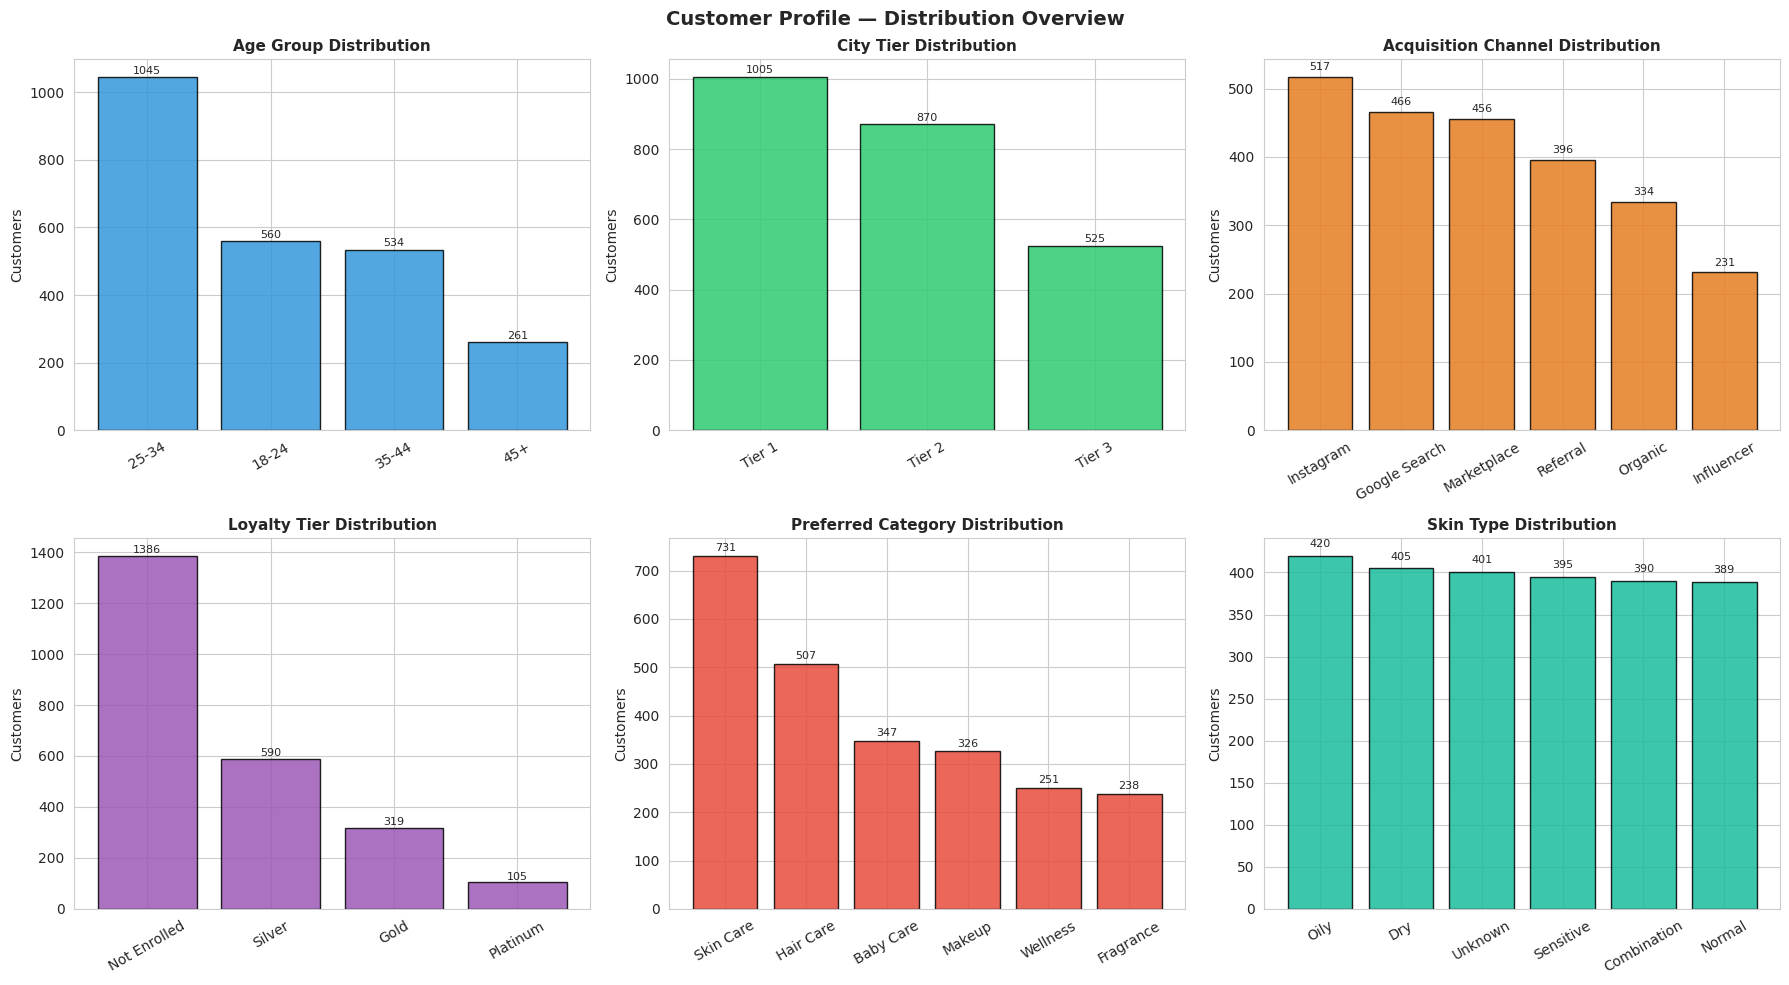

In [92]:
#SECTION 1: CUSTOMER DEMOGRAPHICS
#1.Distribution analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

profile_cols = ['age_group', 'city_tier', 'acquisition_channel',
                'loyalty_tier', 'preferred_category', 'skin_type']

colors = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c','#1abc9c']

for i, col in enumerate(profile_cols):
    counts = customer_churn[col].value_counts(dropna=False)
    axes[i].bar(counts.index.astype(str), counts.values,
                color=colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col.replace("_"," ").title()} Distribution',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Customers')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontsize=8)

plt.suptitle('Customer Profile — Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/d2c_churn/eda_charts/demographics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

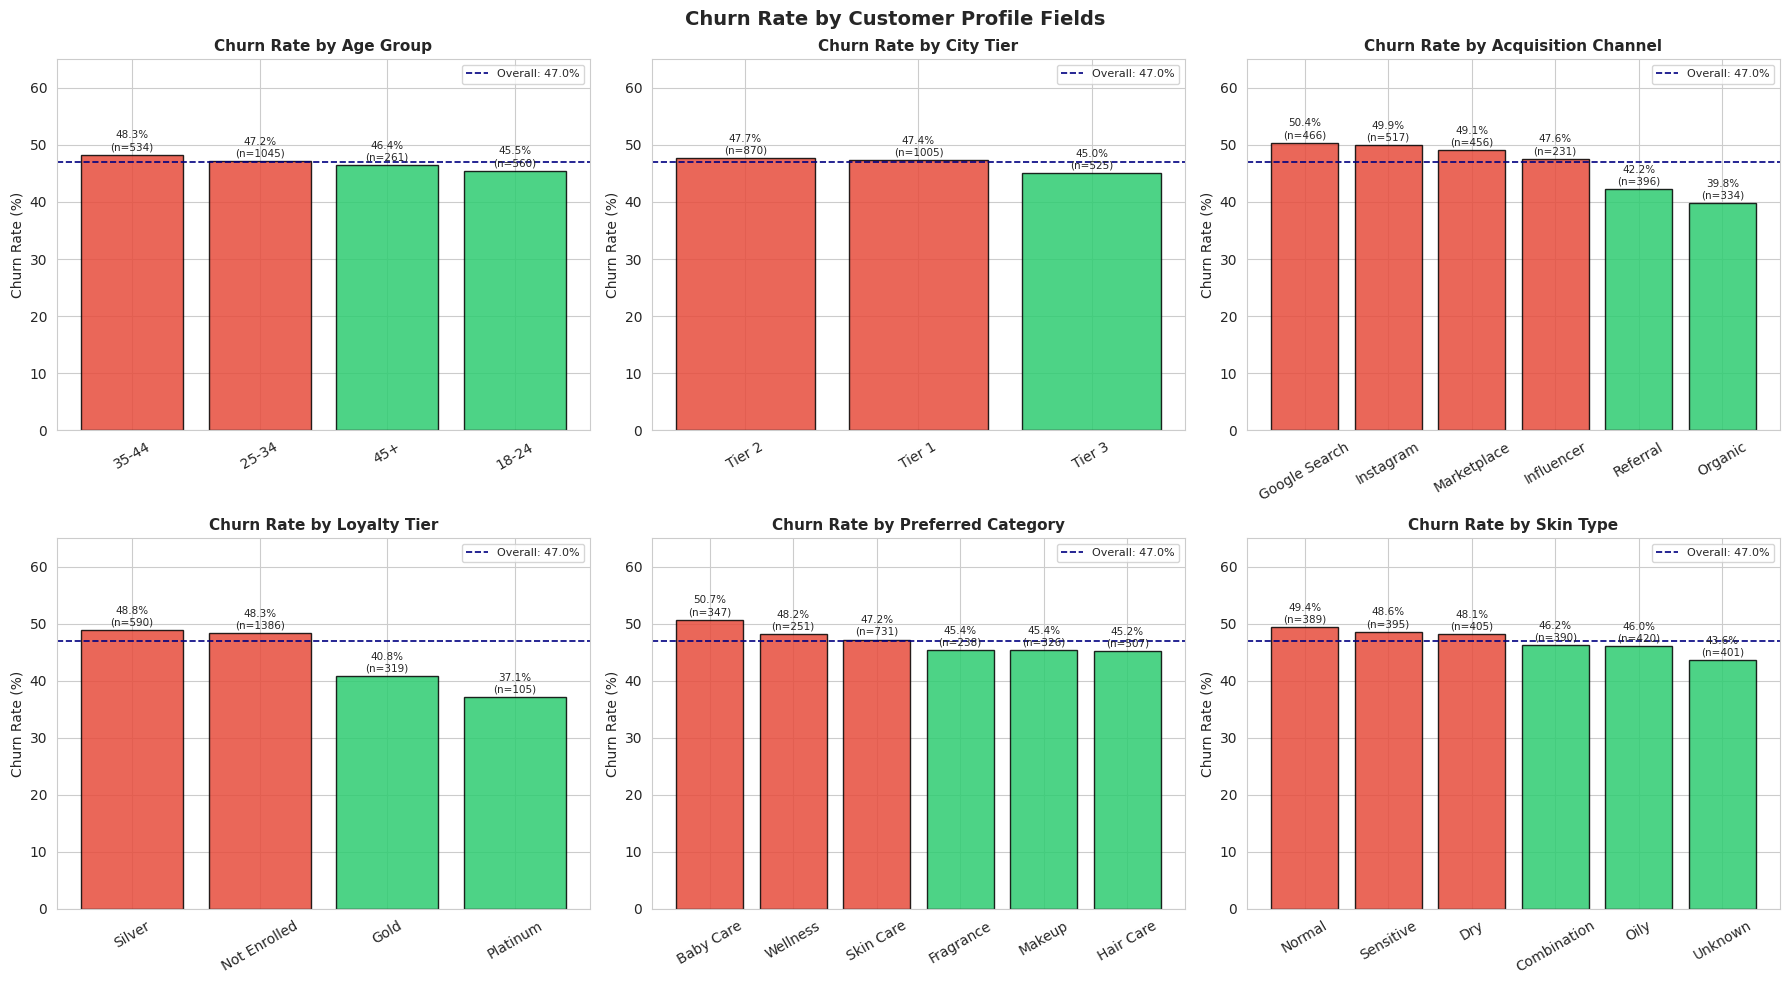

In [93]:
#2.Churn Rate by Each Profile Field
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(profile_cols):
    churn_by = (customer_churn.groupby(col, dropna=False)['churn_next_60d']
                .agg(['mean', 'count']).reset_index())
    churn_by.columns = [col, 'churn_rate', 'n']
    churn_by['churn_rate_pct'] = (churn_by['churn_rate'] * 100).round(1)
    churn_by = churn_by.sort_values('churn_rate_pct', ascending=False)

    bar_colors = ['#e74c3c' if r > churn_rate else '#2ecc71'
                  for r in churn_by['churn_rate_pct']]

    bars = axes[i].bar(churn_by[col].astype(str),
                       churn_by['churn_rate_pct'],
                       color=bar_colors, edgecolor='black', alpha=0.85)

    axes[i].axhline(y=churn_rate, color='navy', linestyle='--',
                    linewidth=1.2, label=f'Overall: {churn_rate:.1f}%')
    axes[i].set_title(f'Churn Rate by {col.replace("_"," ").title()}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 65)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

    for bar, (_, row) in zip(bars, churn_by.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.8,
                     f"{row['churn_rate_pct']}%\n(n={row['n']})",
                     ha='center', fontsize=7.5)

plt.suptitle('Churn Rate by Customer Profile Fields', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/d2c_churn/eda_charts/demographics_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

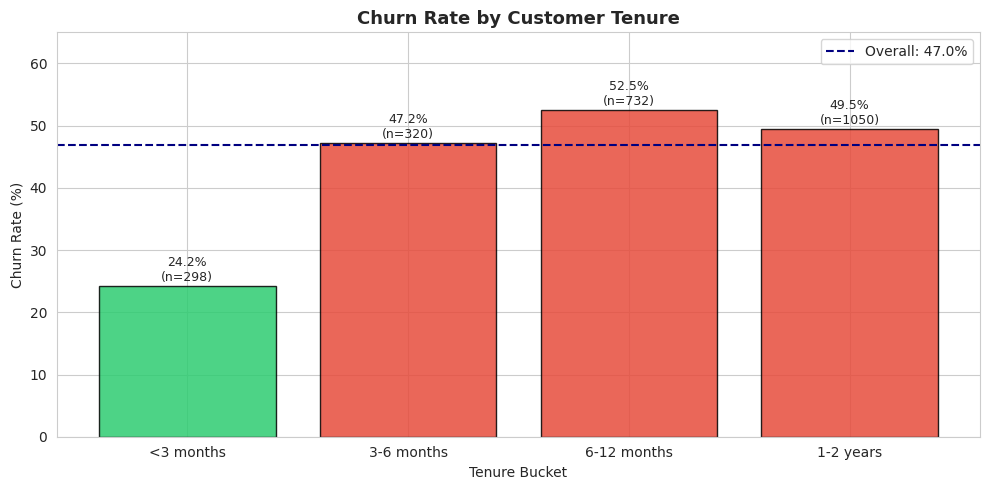

tenure_bucket  churn_rate_pct    n
    <3 months            24.2  298
   3-6 months            47.2  320
  6-12 months            52.5  732
    1-2 years            49.5 1050


In [94]:
#3.Tenure Analysis: Days since signup vs Churn
customer_churn['tenure_days'] = (
    pd.to_datetime('2025-09-30') - customer_churn['signup_date']).dt.days

customer_churn['tenure_bucket'] = pd.cut(
    customer_churn['tenure_days'],
    bins=[0, 90, 180, 365, 730, 9999],
    labels=['<3 months', '3-6 months', '6-12 months', '1-2 years', '2+ years'])

tenure_churn = (customer_churn.groupby('tenure_bucket', observed=True)['churn_next_60d']
                .agg(['mean', 'count']).reset_index())
tenure_churn.columns = ['tenure_bucket', 'churn_rate', 'n']
tenure_churn['churn_rate_pct'] = (tenure_churn['churn_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#e74c3c' if r > churn_rate else '#2ecc71'
              for r in tenure_churn['churn_rate_pct']]
bars = ax.bar(tenure_churn['tenure_bucket'].astype(str),
              tenure_churn['churn_rate_pct'],
              color=bar_colors, edgecolor='black', alpha=0.85)
ax.axhline(y=churn_rate, color='navy', linestyle='--',
           label=f'Overall: {churn_rate:.1f}%')
ax.set_title('Churn Rate by Customer Tenure', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Bucket')
ax.set_ylim(0, 65)
ax.legend()
for bar, (_, row) in zip(bars, tenure_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['churn_rate_pct']}%\n(n={row['n']})",
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/d2c_churn/eda_charts/tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(tenure_churn[['tenure_bucket', 'churn_rate_pct', 'n']].to_string(index=False))

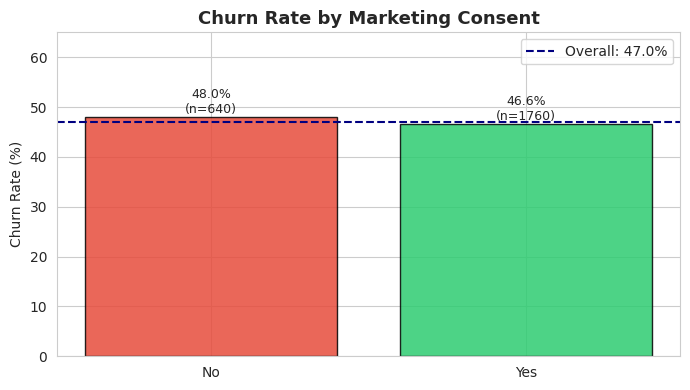

marketing_consent  churn_rate    n  churn_rate_pct
               No    0.479687  640            48.0
              Yes    0.465909 1760            46.6


In [95]:
#4.Marketing Consent vs Churn
consent_churn = (customer_churn.groupby('marketing_consent')['churn_next_60d']
                 .agg(['mean', 'count']).reset_index())
consent_churn.columns = ['marketing_consent', 'churn_rate', 'n']
consent_churn['churn_rate_pct'] = (consent_churn['churn_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#e74c3c' if r > churn_rate else '#2ecc71'
              for r in consent_churn['churn_rate_pct']]
bars = ax.bar(consent_churn['marketing_consent'].astype(str),
              consent_churn['churn_rate_pct'],
              color=bar_colors, edgecolor='black', alpha=0.85)
ax.axhline(y=churn_rate, color='navy', linestyle='--',
           label=f'Overall: {churn_rate:.1f}%')
ax.set_title('Churn Rate by Marketing Consent', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 65)
ax.legend()
for bar, (_, row) in zip(bars, consent_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['churn_rate_pct']}%\n(n={row['n']})",
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/d2c_churn/eda_charts/consent_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(consent_churn.to_string(index=False))


#SECTION 1 — CUSTOMER DEMOGRAPHICS:
##KEY FINDINGS


1. **LOYALTY GAP (Biggest Risk)**:
   
   * 57.75% of customers (1,386) are not enrolled in the loyalty programme.
   * Non-enrolled customers churn at 48.3% compared to Platinum at 37.1%.
   * Churn decreases consistently as loyalty tier increases, indicating a strong relationship between loyalty programme and customer retention.

2. **ACQUISITION CHANNEL RISK:**
   * Google Search (50.4%) and Instagram (49.9%) customers churn above average.
   * Organic channel customers churn at only 39.8%.
   * Acquisition channel appears to be an important factor associated with long-term retention.

3. **Customer Tenure:**
  - Customers with less than 3 months tenure have the lowest churn rate (24.2%).
  - Churn increases substantially after the initial months and peaks at 52.5% for customers with 6–12 months tenure.
  -Retention campaigns should be focused on customers approaching 6–12 months tenure.

4. **Product Preference:**
  - Baby Care customers exhibit the highest churn rate (50.7%).
- Hair Care customers show the lowest churn rate (45.2%).
- Product preference may contribute to churn behaviour.

5. **CITY TIER:**
   Tier 2 cities churn slightly higher (47.7%) than Tier 1 (47.4%) and Tier 3 (45.0%).
   Difference is betwen city tier's is small.

6. **Other Demographic Factors**
- City tier and marketing consent show relatively small differences in churn rates.
- These variables may provide limited standalone predictive power compared with loyalty tier, tenure, and acquisition channel.

#SECTION 2: Order Behaviour & Churn

,order_count
count,2400.000000
mean,4.170417
std,2.626960
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,17.000000


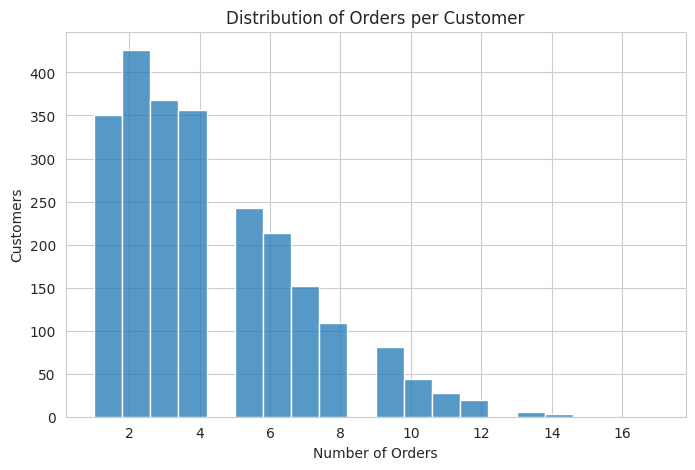

In [96]:
#1.Orders per customer

order_freq = (orders.groupby('customer_id').size().reset_index(name='order_count'))
#left join with churn label
order_freq_churn = order_freq.merge(churn_labels,on='customer_id',how='left')
display(order_freq.describe())
plt.figure(figsize=(8,5))
sns.histplot(order_freq['order_count'], bins=20)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")
plt.show()

### Observations

- Customers place between 1 and 17 orders.
- Half of the customer base has made 4 or fewer purchases.
- Most customers place orders approximately between 2-6.
- The distribution is right-skewed, with customer counts decreasing as order frequency increases.

In [97]:
# Order Count vs Churn Summary

order_churn_summary = (order_freq_churn.groupby('order_count')['churn_next_60d'].agg(['count', 'sum']).reset_index())
order_churn_summary.rename(columns={'count': 'total_customers','sum': 'churned_customers'},inplace=True)
order_churn_summary['retained_customers'] = (order_churn_summary['total_customers']- order_churn_summary['churned_customers'])
order_churn_summary['churn_rate_pct'] = (order_churn_summary['churned_customers']/order_churn_summary['total_customers']* 100).round(1)
order_churn_summary = order_churn_summary[['order_count','retained_customers','churned_customers','total_customers','churn_rate_pct']]
display(order_churn_summary)

,order_count,retained_customers,churned_customers,total_customers,churn_rate_pct
0,1,0,350,350,100.0
1,2,211,215,426,50.5
2,3,190,178,368,48.4
3,4,211,145,356,40.7
4,5,157,86,243,35.4
5,6,149,65,214,30.4
6,7,110,42,152,27.6
7,8,87,22,109,20.2
8,9,72,9,81,11.1
9,10,34,10,44,22.7


,order_bucket,mean,count,churn_rate_pct
0,1 Order,1.000000,350,100.000000
1,2-3 Orders,0.494962,794,49.496222
2,4-5 Orders,0.385643,599,38.564274
3,6-10 Orders,0.246667,600,24.666667
4,10+ Orders,0.087719,57,8.771930


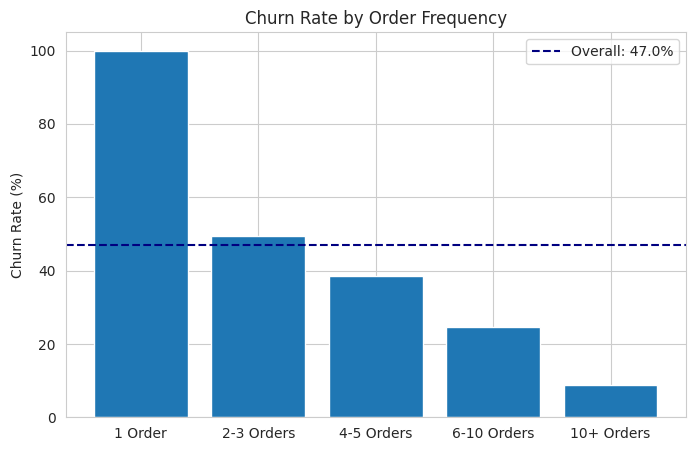

In [98]:
#2.Order Frequency vs Churn
order_freq_churn['order_bucket'] = pd.cut(order_freq_churn['order_count'],
    bins=[0,1,3,5,10,100],labels=['1 Order','2-3 Orders','4-5 Orders',
          '6-10 Orders','10+ Orders'])
freq_churn = (order_freq_churn.groupby('order_bucket')['churn_next_60d'].agg(['mean','count'])
    .reset_index())
freq_churn['churn_rate_pct'] = freq_churn['mean'] * 100
display(freq_churn)
plt.figure(figsize=(8,5))
bars = plt.bar(freq_churn['order_bucket'],freq_churn['churn_rate_pct'])
overall = order_freq_churn['churn_next_60d'].mean()*100
plt.axhline(overall,linestyle='--',
    color='navy',label=f'Overall: {overall:.1f}%')
plt.title("Churn Rate by Order Frequency")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

# Observations

- Churn decreases consistently as order frequency increases.
- Customers with only 1 order exhibit the 100.0%.
- Customers with 10 or more orders exhibit the lowest churn rate (8.8%).
- Customers placing 6–10 orders have a churn rate (24.7%) largely below the overall churn rate of 47.0%.
- The results indicate a strong **inverse relationship** between order frequency and churn.
- Order frequency appears to be one of the strongest behavioral predictors of customer retention.

,recency_days
count,2400.000000
mean,87.375833
std,80.137473
min,0.000000
25%,25.000000
50%,66.000000
75%,129.000000
max,562.000000


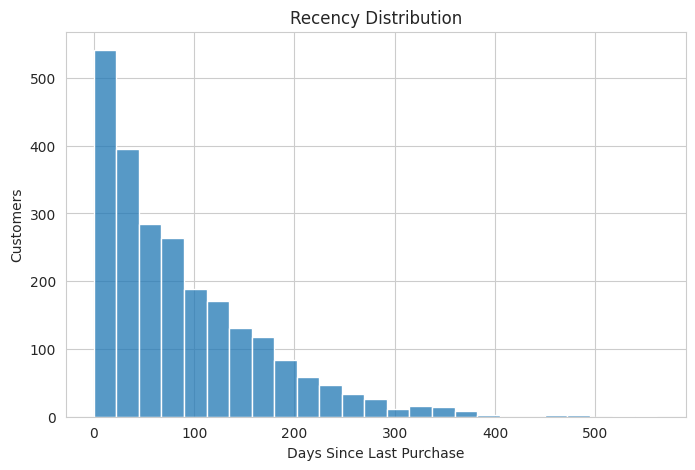

In [99]:
#3.Recency Distribution

display(rfm_snapshot['recency_days'].describe())
plt.figure(figsize=(8,5))
sns.histplot(rfm_snapshot['recency_days'],bins=25)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")
plt.show()

# Observations

- Customer recency ranges from 0 to 562 days.
- Median recency is 66 days,which indicates that half of the customers made a purchase within the last 66 days.
- 75% of customers purchased within the last 129 days.
- The distribution is heavily right-skewed, with most customers making relatively recent purchases and a smaller group remaining inactive for extended periods.

,recency_bucket,mean,count,churn_rate_pct
0,0-30 Days,0.117310,699,11.7
1,31-60 Days,0.303855,441,30.4
2,61-90 Days,0.457064,361,45.7
3,91-180 Days,0.787270,597,78.7
4,180+ Days,0.913907,302,91.4


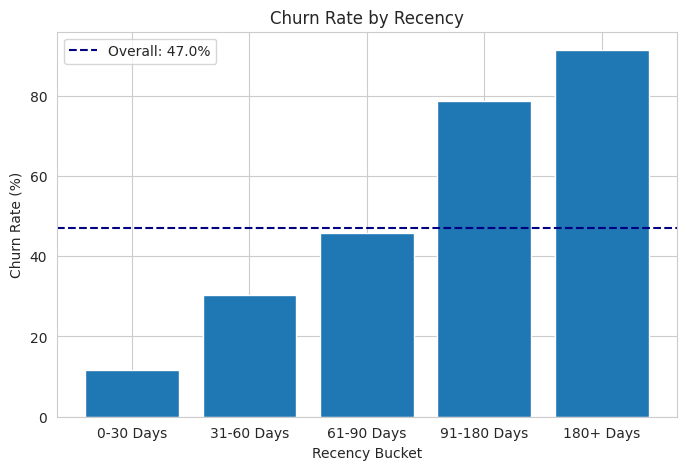

In [100]:
#4.Recency vs Churn
# Create recency buckets
rfm_snapshot['recency_bucket'] = pd.cut(rfm_snapshot['recency_days'],
    bins=[0, 30, 60, 90, 180,rfm_snapshot['recency_days'].max()],
    labels=['0-30 Days','31-60 Days','61-90 Days',
        '91-180 Days','180+ Days'],include_lowest=True)
#Churn summary
recency_summary = (rfm_snapshot.groupby('recency_bucket')['churn_next_60d'].agg(['mean', 'count']).reset_index())
#Convert to percentage
recency_summary['churn_rate_pct'] = (recency_summary['mean'] * 100).round(1)
display(recency_summary)
#Overall churn rate
overall_churn = rfm_snapshot['churn_next_60d'].mean() * 100
# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(recency_summary['recency_bucket'],recency_summary['churn_rate_pct'])
plt.axhline(overall_churn,linestyle='--',color='navy',label=f'Overall: {overall_churn:.1f}%')
plt.title('Churn Rate by Recency')
plt.xlabel('Recency Bucket')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

# Observations

- Churn increases as recency increases.
- Customers who purchased within the last 30 days show the lowest churn rate at 11.7%.
- Customers inactive for 91–180 days exhibit a churn rate of 78.7%, significantly above the overall churn rate of 47.0%.
- Customers inactive for more than 180 days have the highest churn rate at 91.4%.
-This indicates a strong positive relationship between inactivity and churn risk.

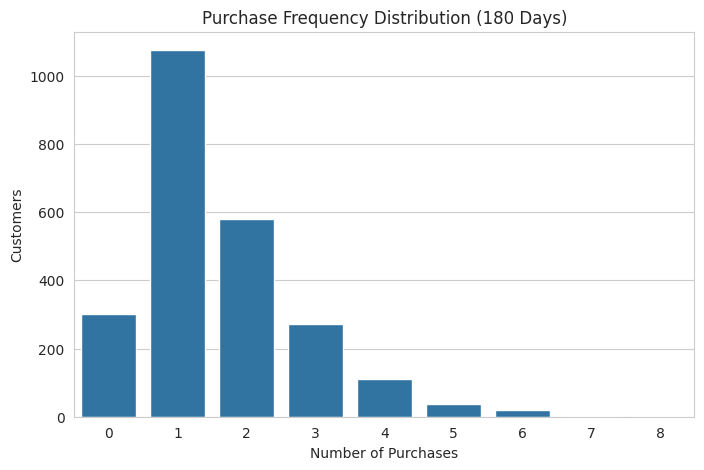

,frequency_180d
count,2400.000000
mean,1.594583
std,1.184964
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,8.000000


In [101]:
#5.Frequency (180 Days) Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='frequency_180d',data=rfm_snapshot)
plt.title("Purchase Frequency Distribution (180 Days)")
plt.xlabel("Number of Purchases")
plt.ylabel("Customers")
plt.show()
display(rfm_snapshot['frequency_180d'].describe())

# Observations

- Purchase frequency over the last 180 days ranges from 0 to 8 purchases.
- The average customer made approximately 1.6 purchases during the last 180 days.
- 75% of customers made two or fewer purchases in the last 180 days.
- The distribution is positively skewed, with a large concentration of customers making 1–2 orders and few customers making frequent purchases.
- A small group of customers made more than 5 purchases during the last 180 days.

,frequency_bucket,mean,count,churn_rate_pct
0,0 Purchases,0.913907,302,91.4
1,1 Purchase,0.531163,1075,53.1
2,2 Purchases,0.359240,579,35.9
3,3+ Purchases,0.162162,444,16.2


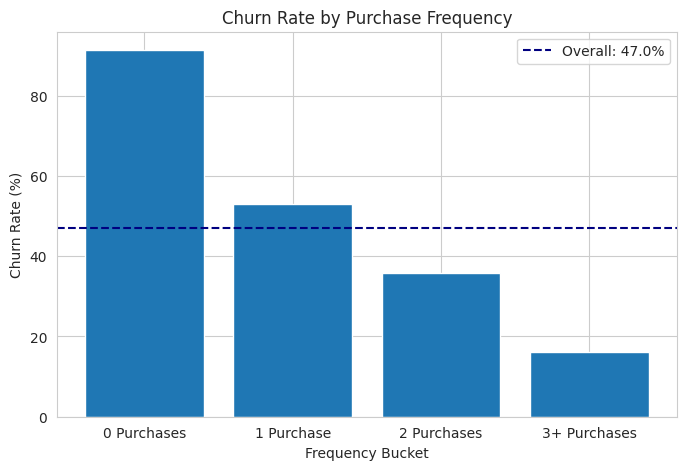

In [102]:
#6.Purchase Frequency vs Churn
freq_df = rfm_snapshot.copy()
freq_df['frequency_bucket'] = pd.cut(freq_df['frequency_180d'],bins=[-1, 0, 1, 2, 8],
    labels=[
        '0 Purchases',
        '1 Purchase',
        '2 Purchases',
        '3+ Purchases'],include_lowest=True)
freq_churn = (freq_df.groupby('frequency_bucket')['churn_next_60d'].agg(['mean','count']).reset_index())
freq_churn['churn_rate_pct'] = (freq_churn['mean'] * 100).round(1)
display(freq_churn)
overall = freq_df['churn_next_60d'].mean() * 100
plt.figure(figsize=(8,5))
plt.bar(freq_churn['frequency_bucket'],freq_churn['churn_rate_pct'])
plt.axhline(overall,linestyle='--',color='navy',label=f'Overall: {overall:.1f}%')
plt.title("Churn Rate by Purchase Frequency")
plt.xlabel("Frequency Bucket")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

# Observations

- Churn decreases consistently as purchase frequency increases.
- Customers with no purchases in the last 180 days exhibit the highest churn rate at 91.4%.
- Customers with 1 purchase exhibit a churn rate of 53.1%, slightly above the overall churn rate of 47.0%.
- Customers with 2 purchases exhibit a churn rate of 35.9%.
- Customers with 3+ purchases exhibit the lowest churn rate at 16.2%.
- This indicates a strong inverse relationship between purchase frequency and churn.

#SECTION 3:Monetary Behaviour

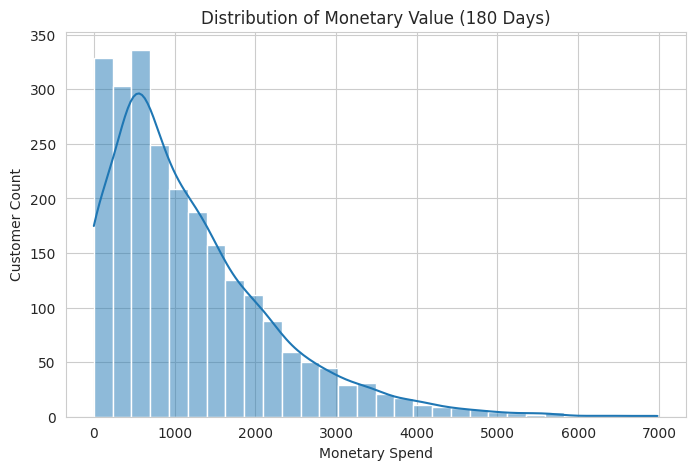

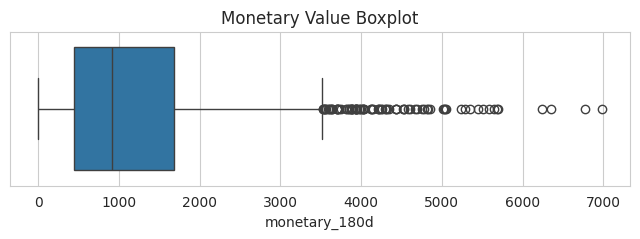

In [103]:
# Monetary Value Distribution (Last 180 Days)
# Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(rfm_snapshot['monetary_180d'],bins=30,kde=True)
plt.title("Distribution of Monetary Value (180 Days)")
plt.xlabel("Monetary Spend")
plt.ylabel("Customer Count")
plt.show()
# Box Plot
plt.figure(figsize=(8,2))
sns.boxplot(x=rfm_snapshot['monetary_180d'])
plt.title("Monetary Value Boxplot")
plt.show()

# Observation

- Customer spending over the last 180 days is positively right skewed.
- The majority of customers are concentrated in the lower spending ranges.
- Customer count declines steadily as monetary spend increases.
- A relatively small group of customers contributes substantially higher spending amounts.
- The distribution contains a long right tail, indicating the presence of high-value customers.
- Very few customers spend above ₹4,000, while most customers appear to spend below ₹2,000.

,monetary_bucket,mean,count,churn_rate_pct
0,Low Spend,0.756667,600,75.7
1,Medium-Low,0.506667,600,50.7
2,Medium-High,0.408333,600,40.8
3,High Spend,0.206667,600,20.7


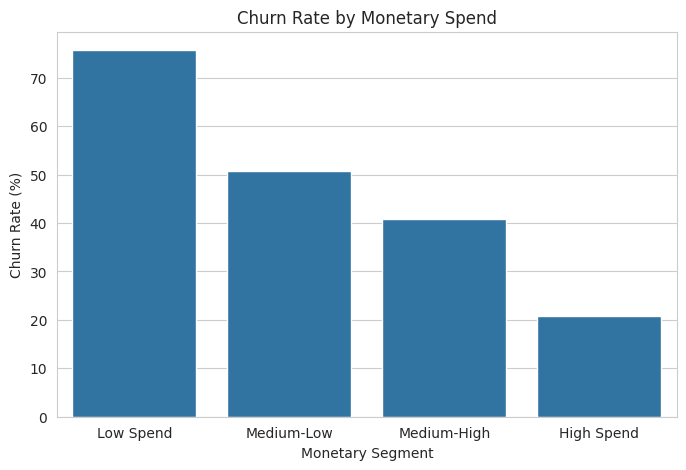

In [104]:
#Churn Rate by Monetary Spend
rfm_snapshot['monetary_bucket'] = pd.qcut(
    rfm_snapshot['monetary_180d'],q=4,
    labels=[
        'Low Spend',
        'Medium-Low',
        'Medium-High',
        'High Spend'])
monetary_churn = (rfm_snapshot.groupby('monetary_bucket')['churn_next_60d']
    .agg(['mean','count']).reset_index())
monetary_churn['churn_rate_pct'] =(monetary_churn['mean'] * 100).round(1)
display(monetary_churn)

#Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=monetary_churn,x='monetary_bucket',y='churn_rate_pct')
plt.title('Churn Rate by Monetary Spend')
plt.xlabel('Monetary Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

# Observation

- Low Spend customers exhibit a churn rate of 75.7%.
- Medium-Low customers exhibit a churn rate of 50.7%.
- Medium-High customers exhibit a churn rate of 40.8%.
- High Spend customers exhibit a churn rate of 20.7%.
- Churn risk decreases consistently as customer spending increases.
- The difference between the lowest and highest spending segments is 55.0 percentage points.
- High Spend customers churn at less than one-third the rate of Low Spend customers.
- The relationship appears monotonic, indicating a strong inverse association between customer value and churn risk.

In [105]:
rfm_snapshot['return_rate_180d'].describe()
rfm_snapshot['return_rate_180d'].quantile([0.25,0.50,0.75,0.90,0.95,0.99])

,return_rate_180d
0.25,0.00
0.50,0.00
0.75,0.00
0.90,0.25
0.95,0.50
0.99,1.00


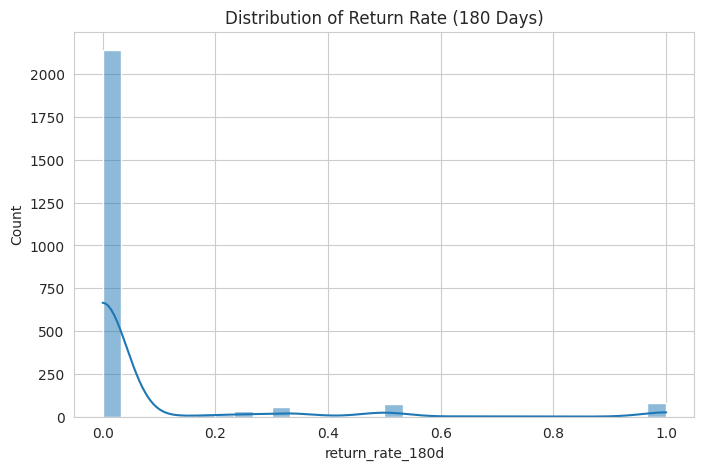

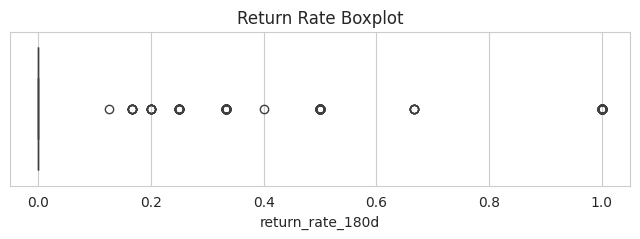

In [106]:
#Return Rate Distribution
plt.figure(figsize=(8,5))
sns.histplot(rfm_snapshot['return_rate_180d'], bins=30, kde=True)
plt.title("Distribution of Return Rate (180 Days)")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=rfm_snapshot['return_rate_180d'])
plt.title("Return Rate Boxplot")
plt.show()


# Observation

- Return rate is heavily concentrated at 0.
- The 25th, 50th, and 75th percentiles are all 0.00, indicating that at least 75% of customers did not return any orders during the last 180 days.
- Only 10% of customers have a return rate greater than 25%.
- Only 5% of customers have a return rate greater than 50%.
- The distribution is extremely right-skewed with a large spike at zero and a long tail extending toward 1.0.
- A small subset of customers exhibit very high return behavior, including some customers who returned all of their purchases during the observation window.
- The boxplot shows numerous high-value outliers, representing customers with unusually high return rates.

,return_bucket,mean,count,churn_rate_pct
0,No Returns,0.471522,2142,47.2
1,Low Returns (0-25%),0.086957,46,8.7
2,Moderate Returns (25-50%),0.390625,128,39.1
3,High Returns (>50%),0.750000,84,75.0


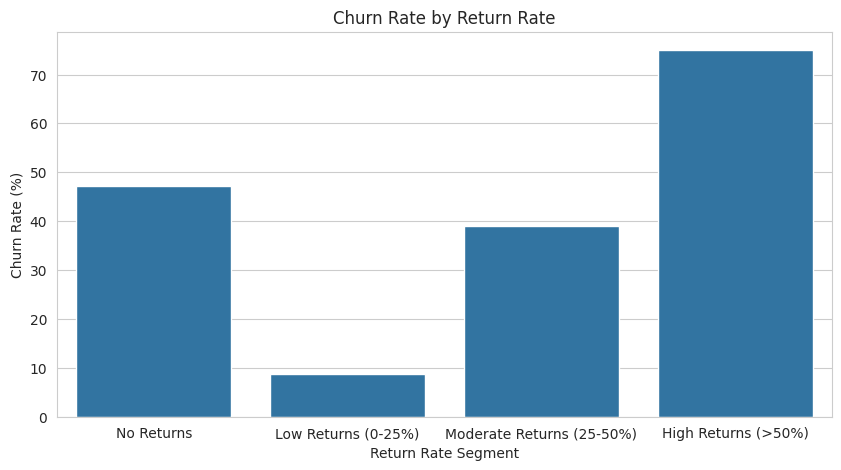

In [107]:
#Churn Rate by Return Rate
rfm_snapshot['return_bucket'] = pd.cut(
    rfm_snapshot['return_rate_180d'],
    bins=[-0.01, 0, 0.25, 0.50, 1.0],
    labels=[
        'No Returns',
        'Low Returns (0-25%)',
        'Moderate Returns (25-50%)',
        'High Returns (>50%)'])
return_churn = (rfm_snapshot.groupby('return_bucket')['churn_next_60d'].agg(['mean','count']).reset_index())
return_churn['churn_rate_pct'] = (return_churn['mean'] * 100).round(1)
display(return_churn)

#visualization
plt.figure(figsize=(10,5))
sns.barplot(data=return_churn,x='return_bucket',y='churn_rate_pct')
plt.title('Churn Rate by Return Rate')
plt.xlabel('Return Rate Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

# Observation

- Customers with no returns exhibit a churn rate of 47.2%.
- Customers with low return rates (0–25%) exhibit the lowest churn rate at 8.7%.
- Customers with moderate return rates (25–50%) exhibit a churn rate of 39.1%.
- Customers with high return rates (>50%) exhibit the highest churn rate at 75.0%.
- The relationship between return behavior and churn is non-linear rather than strictly increasing.
- Churn risk is lowest among customers who occasionally return products, but rises sharply among customers with very high return rates.
### Note

The Low Return segment contains a relatively small number of customers (n=46). While the observed churn rate is low, this should be interpreted with caution due to the limited sample size.

Average Discount Statistics
count    2400.000000
mean        0.245094
std         0.139805
min         0.000000
25%         0.160000
50%         0.260000
75%         0.340000
max         0.700000
Name: avg_discount_pct_180d, dtype: float64

Median Discount:
0.26

Percentiles
0.25    0.16
0.50    0.26
0.75    0.34
0.90    0.41
0.95    0.45
0.99    0.56
Name: avg_discount_pct_180d, dtype: float64


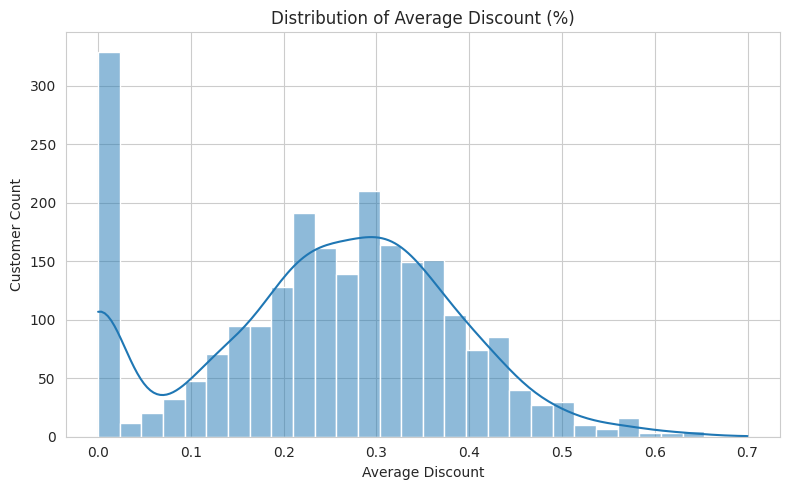

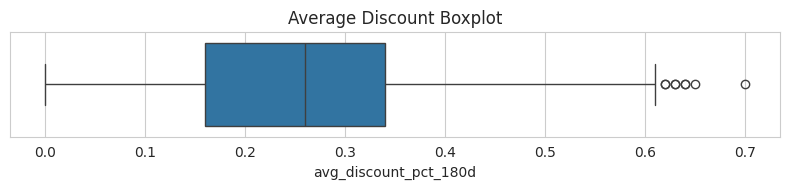

In [108]:
#Average Discount Distribution
print("Average Discount Statistics")
print(rfm_snapshot['avg_discount_pct_180d'].describe())
# Median
print("\nMedian Discount:")
print(rfm_snapshot['avg_discount_pct_180d'].median())
# Percentiles
print("\nPercentiles")
print(rfm_snapshot['avg_discount_pct_180d'].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(rfm_snapshot['avg_discount_pct_180d'],bins=30,kde=True)
plt.title("Distribution of Average Discount (%)")
plt.xlabel("Average Discount")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()
#Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=rfm_snapshot['avg_discount_pct_180d'])
plt.title("Average Discount Boxplot")
plt.tight_layout()
plt.show()

# Observations

- Average discounts range from 0% to 70% across the customer base.
- Histogram shows a **spike at 0%** followed by a broad peak around **25–30%**, causing mean (**24.5%**) to fall below median (**26%**)
- Core of the distribution lies between **16%–34%** (IQR), covering 50% of customers
- Boxplot confirms **tight central spread** with a few outliers beyond **60%**, likely special pricing cases


,discount_bucket,mean,count,churn_rate_pct
0,Low Discount,0.676568,606,67.7
1,Medium-Low,0.362620,626,36.3
2,Medium-High,0.384746,590,38.5
3,High Discount,0.455017,578,45.5


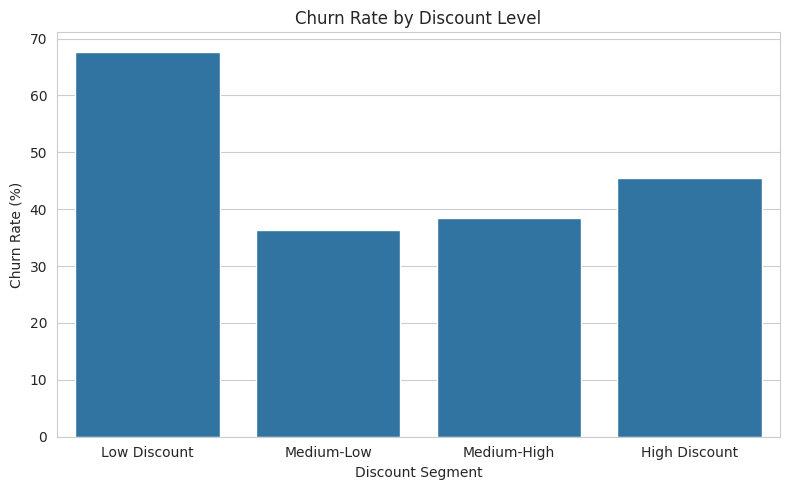

In [109]:
#Churn Rate by Discount Level

rfm_snapshot['discount_bucket'] = pd.qcut(rfm_snapshot['avg_discount_pct_180d'],
    q=4,labels=[
        'Low Discount',
        'Medium-Low',
        'Medium-High',
        'High Discount'])
discount_churn = (rfm_snapshot.groupby('discount_bucket')['churn_next_60d'].agg(['mean', 'count']).reset_index())
discount_churn['churn_rate_pct'] = (discount_churn['mean'] * 100).round(1)
display(discount_churn)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=discount_churn,x='discount_bucket',y='churn_rate_pct')
plt.title('Churn Rate by Discount Level')
plt.xlabel('Discount Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Churn Rate by Discount Level — Observations

- **Low Discount** customers have the highest churn at **67.7%**,nearly double other segments
- Churn drops sharply to **~36–38%** for **Medium-Low and Medium-High** segments, suggesting discounts in the **16–34% range** are most effective at retention
- **High Discount** customers churn at **45.5%**,higher than medium tiers, implying heavy discounts alone don't prevent churn
- The relationship between discount level and churn is non-linear.

##SECTION 4 — Product Experience & Churn

Average Rating Statistics
count    2400.000000
mean        3.847092
std         0.923442
min         1.000000
25%         3.500000
50%         4.000000
75%         4.500000
max         5.000000
Name: avg_rating_180d, dtype: float64

Median Rating: 4.0

Percentiles
0.25    3.5
0.50    4.0
0.75    4.5
0.90    5.0
0.95    5.0
0.99    5.0
Name: avg_rating_180d, dtype: float64


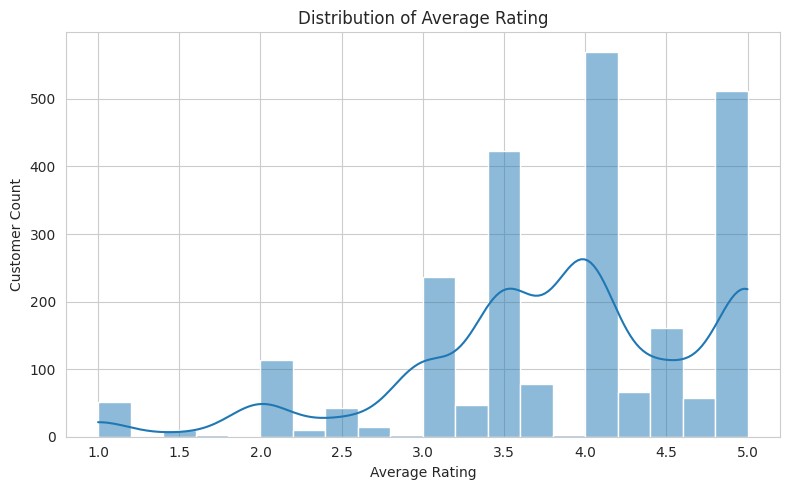

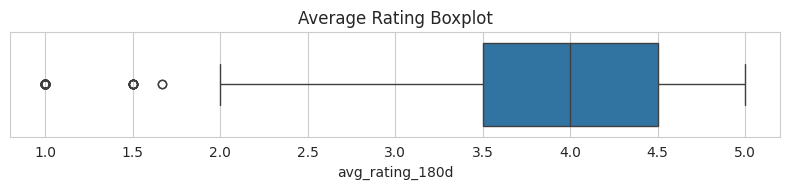

In [110]:
#Average Rating Distribution

print("Average Rating Statistics")
print(rfm_snapshot['avg_rating_180d'].describe())
# Median
print("\nMedian Rating:",rfm_snapshot['avg_rating_180d'].median())

# Percentiles
print("\nPercentiles")
print(rfm_snapshot['avg_rating_180d'].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(rfm_snapshot['avg_rating_180d'],bins=20,kde=True)
plt.title("Distribution of Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

#Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=rfm_snapshot['avg_rating_180d'])
plt.title("Average Rating Boxplot")
plt.tight_layout()
plt.show()

# Observation

- Ratings range **1.0–5.0**, mean **3.85** and median **4.0**
-50% of customers fall between **3.5–4.5**
- Distribution is **right-concentrated** .
-90th percentile and above all score **5.0**, with low-rated customers being a small minority

,rating_bucket,mean,count,churn_rate_pct
0,Low (1-2),0.519774,177,52.0
1,Below Avg (2-3),0.434641,306,43.5
2,Good (3-4),0.529044,1119,52.9
3,Excellent (4-5),0.388471,798,38.8


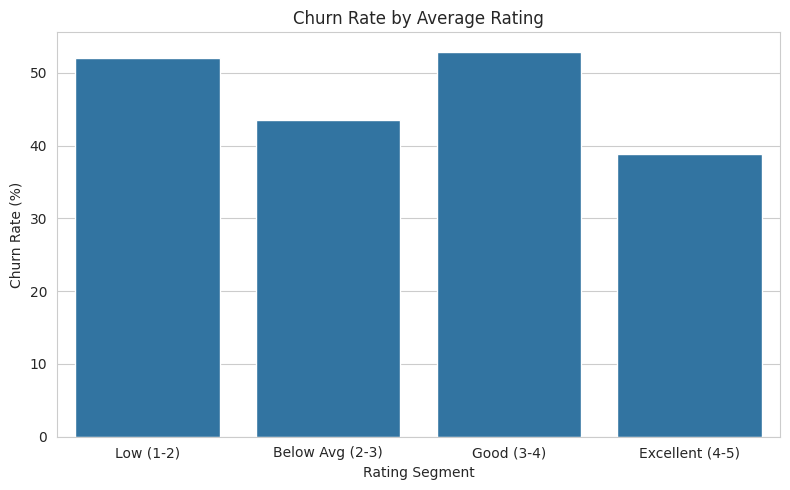

In [111]:
#Churn Rate by Average Rating

rfm_snapshot['rating_bucket'] = pd.cut(rfm_snapshot['avg_rating_180d'],
    bins=[0, 2, 3, 4, 5],
    labels=[
        'Low (1-2)',
        'Below Avg (2-3)',
        'Good (3-4)',
        'Excellent (4-5)'])
rating_churn = (rfm_snapshot.groupby('rating_bucket')['churn_next_60d'].agg(['mean', 'count']).reset_index())
rating_churn['churn_rate_pct'] = (rating_churn['mean'] * 100).round(1)
display(rating_churn)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=rating_churn,x='rating_bucket',y='churn_rate_pct')
plt.title('Churn Rate by Average Rating')
plt.xlabel('Rating Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

#Observations

- **Excellent (4–5)** customers churn least at **38.8%**, while **Good (3–4)** the largest segment, leads churn at **52.9%**
- No linear trend between ratings and churn.
- Customers with **Excellent Ratings** show better retention than all other rating segments.


Category Diversity Statistics
count    2400.000000
mean        1.375417
std         0.896650
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: category_diversity_180d, dtype: float64

Median: 1.0

Percentiles
0.25    1.0
0.50    1.0
0.75    2.0
0.90    3.0
0.95    3.0
0.99    4.0
Name: category_diversity_180d, dtype: float64

Category Diversity Counts category_diversity_180d
0     302
1    1220
2     607
3     219
4      50
5       2
Name: count, dtype: int64


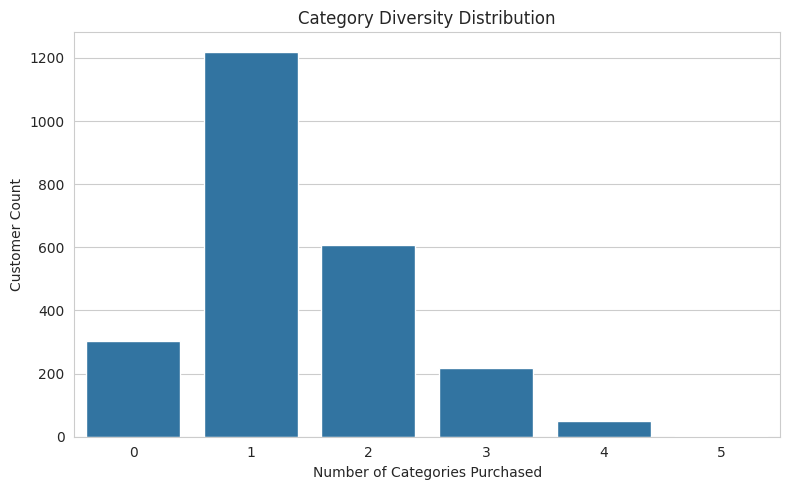

In [112]:
#Category Diversity Distribution
print("Category Diversity Statistics")
print(rfm_snapshot['category_diversity_180d'].describe())
# Median
print("\nMedian:", rfm_snapshot['category_diversity_180d'].median())
# Percentiles
print("\nPercentiles")
print(rfm_snapshot['category_diversity_180d'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# Value Counts
print("\nCategory Diversity Counts", rfm_snapshot['category_diversity_180d'].value_counts().sort_index())
# Distribution Plot
plt.figure(figsize=(8,5))
sns.countplot(data=rfm_snapshot,x='category_diversity_180d')
plt.title('Category Diversity Distribution')
plt.xlabel('Number of Categories Purchased')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

##Observations

- More than half of the customer base (1,220 customers) purchases from only a single category.
- Approximately 75% of customers purchase from two or fewer categories.
- Only a small proportion of customers purchase across four or more categories.
- A notable group of 302 customers has a category diversity of 0, indicating no purchases during the 180-day observation window.

,category_diversity_180d,mean,count,churn_rate_pct
0,0,0.913907,302,91.4
1,1,0.504918,1220,50.5
2,2,0.314662,607,31.5
3,3,0.168950,219,16.9
4,4,0.100000,50,10.0
5,5,1.000000,2,100.0


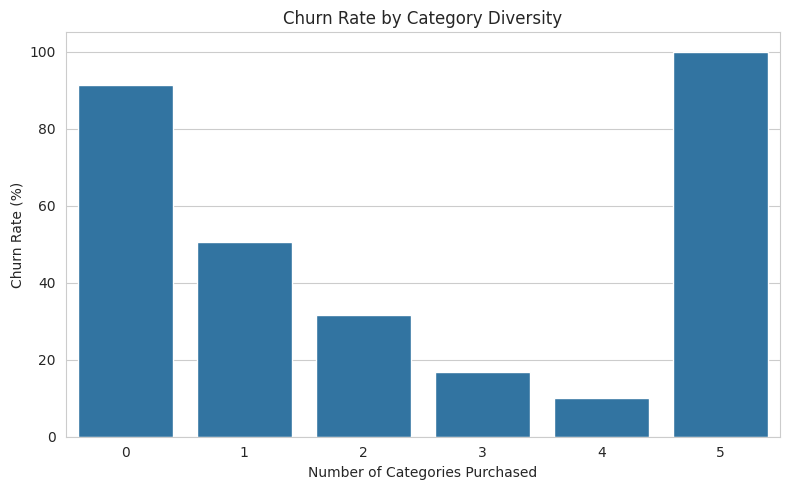

In [113]:
# Churn Rate by Category Diversity
diversity_churn = (rfm_snapshot.groupby('category_diversity_180d')['churn_next_60d']
    .agg(['mean', 'count']).reset_index())
diversity_churn['churn_rate_pct'] = (diversity_churn['mean'] * 100).round(1)
display(diversity_churn)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=diversity_churn,x='category_diversity_180d',y='churn_rate_pct')
plt.title('Churn Rate by Category Diversity')
plt.xlabel('Number of Categories Purchased')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Churn Rate by Category Diversity — Observations

- Churn drops **consistently and steeply** with diversity: **91.4% → 50.5% → 31.5% → 16.9% → 10.0%** for 0 to 4 categories,**monotonic relationship**
- Customers with **0 purchases** churn at **91.4%**, confirming they are largely inactive/lapsed.
- Engaging customers across even **2 categories** cuts churn by nearly **60%** compared to single-category buyers.
- Diversity = 5 shows **100% churn** but is based on only **2 customers** and should not be generalized.

In [114]:
##SECTION 5 — Support Ticket Issues & Churn

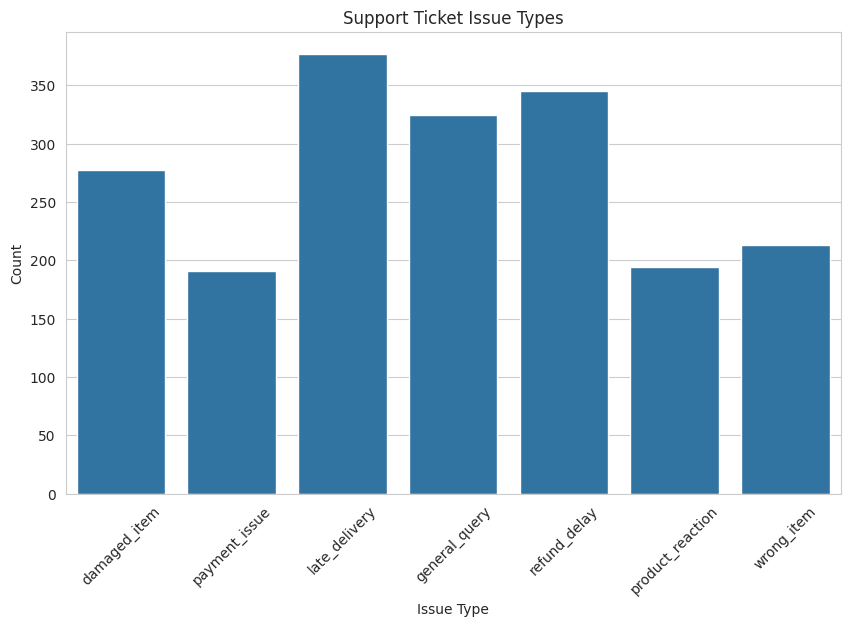

In [115]:
#Support Ticket Issue Types
sns.countplot(data=support_tickets,x='issue_type')
plt.xticks(rotation=45)
plt.title('Support Ticket Issue Types')
plt.xlabel('Issue Type')
plt.ylabel('Count')
plt.show()

### Support Ticket Issue Types — Analysis

Total tickets raised: 1,921 across 7 issue categories.

- (highest) **late_delivery:** ~375 logistics failure
- **refund_delay:** ~345 financial frustration
- **general_query:** ~325 non-critical but high volume.
- **damaged_item:** ~278 fulfilment quality issue.
- **wrong_item:** ~213 fulfilment accuracy issue.
- **product_reaction:** ~195 health/safety concern.
-(lowest) **payment_issue:** ~190

Late delivery and refund delays together account for ~720 tickets
(37% of all tickets) — both are post-purchase failures that
directly damage trust and increase churn risk.

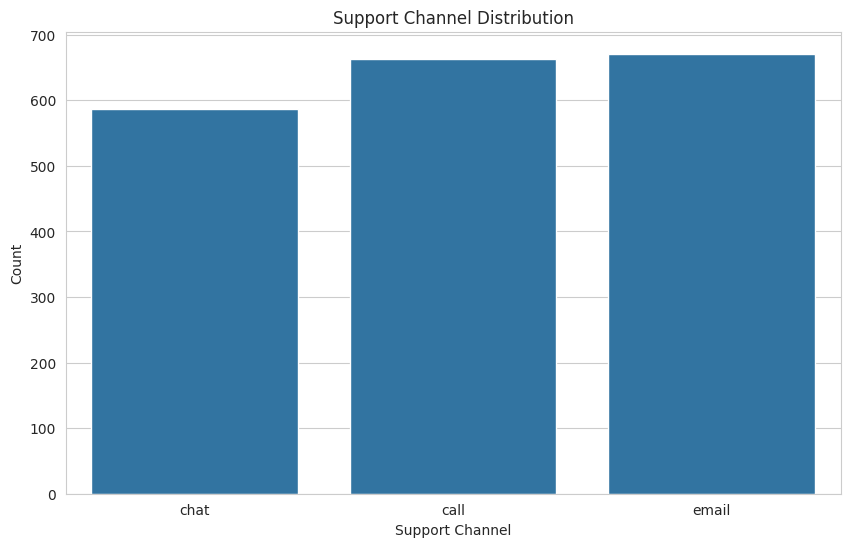

In [116]:
#Support Channel Distribution
sns.countplot(data=support_tickets,x='support_channel')
plt.title('Support Channel Distribution')
plt.xlabel('Support Channel')
plt.ylabel('Count')
plt.show()

### Support Channel Distribution — Analysis

Tickets are fairly evenly spread across all three channels.

- Email: ~670 (highest)
- Call: ~665
- Chat: ~586 (lowest)

* Email and call dominates,suggesting customers prefer channels where they can explain complex issues in detail.

* The near-equal
distribution means no single channel is overloaded, but also that customers are not being guided toward faster self-service options like chat.

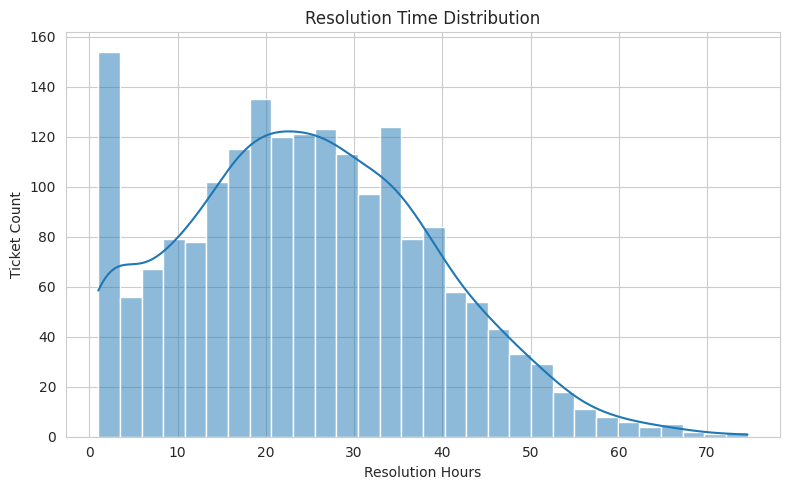

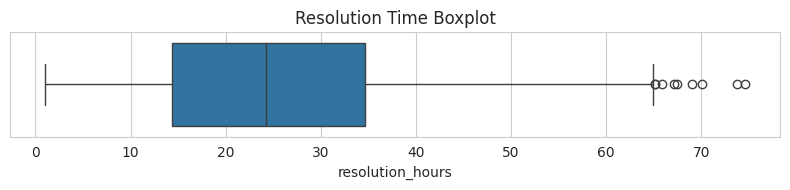

In [117]:
# Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(support_tickets['resolution_hours'],bins=30,kde=True)
plt.title('Resolution Time Distribution')
plt.xlabel('Resolution Hours')
plt.ylabel('Ticket Count')
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=support_tickets['resolution_hours'])
plt.title('Resolution Time Boxplot')
plt.tight_layout()
plt.show()

###OBSERVATION


- Distribution is **right-skewed** with a spike at **0–2 hours** (quick resolutions) followed by a broad peak between **20–35 hours**
- Boxplot confirms core resolution window of **15–35 hours** (IQR), with median around **25 hours**
- Outliers beyond **60+ hours** represent a small subset of complex or delayed tickets requiring attention

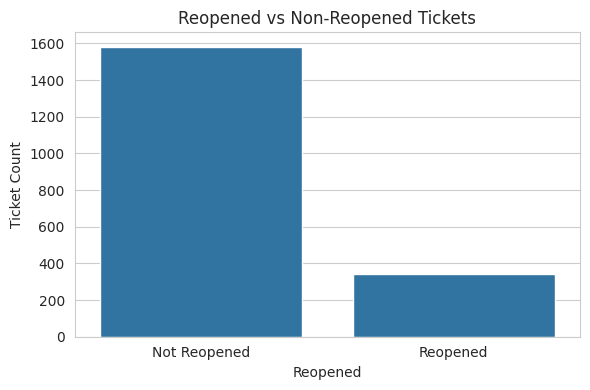

In [118]:
#Reopened Ticket Distribution
# Visualization
plt.figure(figsize=(6,4))
sns.countplot(data=support_tickets,x='reopened')
plt.title('Reopened vs Non-Reopened Tickets')
plt.xlabel('Reopened')
plt.ylabel('Ticket Count')
plt.xticks(ticks=[0, 1],labels=['Not Reopened', 'Reopened'])
plt.tight_layout()
plt.show()

## Reopened vs Non-Reopened Tickets — Observations

- **1,580 tickets (~82%)** were resolved without reopening, while **340 tickets (~18%)** required reopening


,ticket_bucket,mean,count,churn_rate_pct
0,No Tickets,0.505783,1902,50.6
1,1 Ticket,0.351893,449,35.2
2,2+ Tickets,0.152174,46,15.2


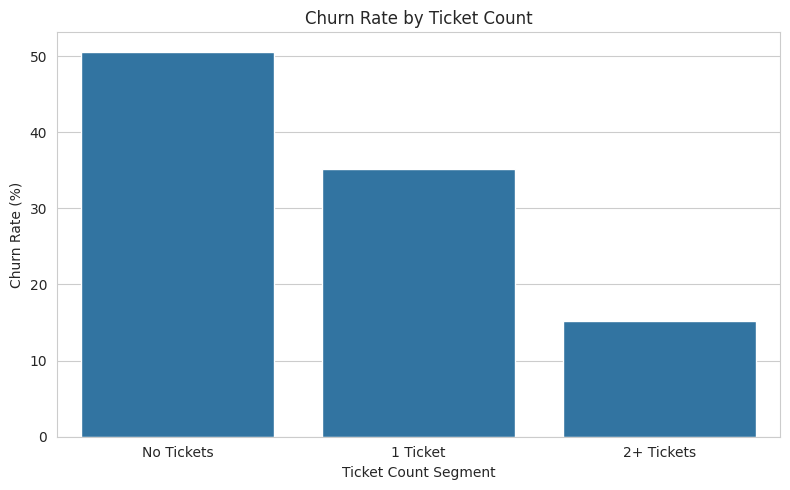

In [119]:
#Churn Rate by Ticket Count
rfm_snapshot['ticket_bucket'] = pd.cut(rfm_snapshot['ticket_count_90d'],bins=[-1, 0, 1, 2],
    labels=['No Tickets','1 Ticket','2+ Tickets'])
ticket_churn = (rfm_snapshot.groupby('ticket_bucket')['churn_next_60d']
    .agg(['mean', 'count']).reset_index())
ticket_churn['churn_rate_pct'] = (ticket_churn['mean'] * 100).round(1)
display(ticket_churn)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=ticket_churn,x='ticket_bucket',y='churn_rate_pct')
plt.title('Churn Rate by Ticket Count')
plt.xlabel('Ticket Count Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()



## Churn Rate by Support Ticket Activity — Observations

- Churn decreases **consistently** with ticket activity: **50.6% → 35.2% → 15.2%** for 0, 1, and 2+ tickets
- Counterintuitively, customers who **engage with support churn far less** ,suggesting support interaction signals active involvement rather than dissatisfaction
- **1,902 customers (~79%)** raised no tickets, forming the largest and highest-churn segment

,negative_ticket_flag,mean,count,churn_rate_pct
0,At Least One Negative Ticket,0.374269,342,37.4
1,No Negative Tickets,0.485423,2058,48.5


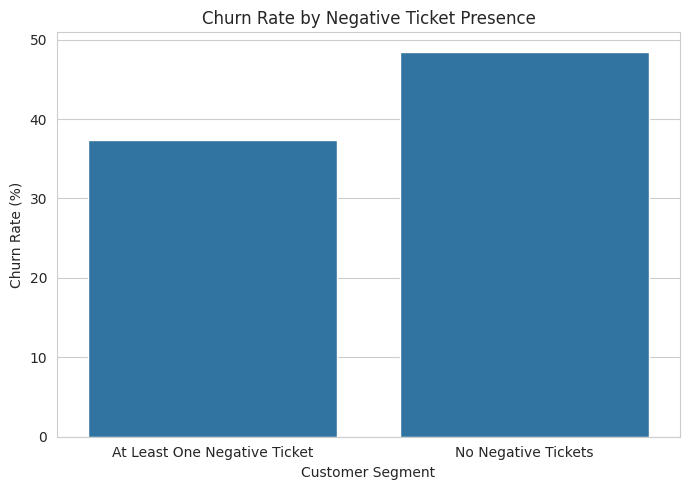

In [120]:
#Churn Rate by Negative Ticket Presence
rfm_snapshot['negative_ticket_flag'] = np.where(rfm_snapshot['negative_ticket_rate_90d'] > 0,
    'At Least One Negative Ticket','No Negative Tickets')

negative_churn = (rfm_snapshot.groupby('negative_ticket_flag')['churn_next_60d'].agg(['mean', 'count']).reset_index())
negative_churn['churn_rate_pct'] = (negative_churn['mean'] * 100).round(1)
display(negative_churn)
plt.figure(figsize=(7,5))
sns.barplot(data=negative_churn,x='negative_ticket_flag',y='churn_rate_pct')
plt.title('Churn Rate by Negative Ticket Presence')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

## Churn Rate by Negative Ticket — Observations

- Customers with no negative support interactions exhibit a churn rate of 48.5%.
- The majority of customers (2,058) belong to the no-negative-ticket segment, while 342 customers have experienced at least one negative support interaction.
- The observed relationship suggests that support engagement may be more influential than support sentiment in determining customer retention.

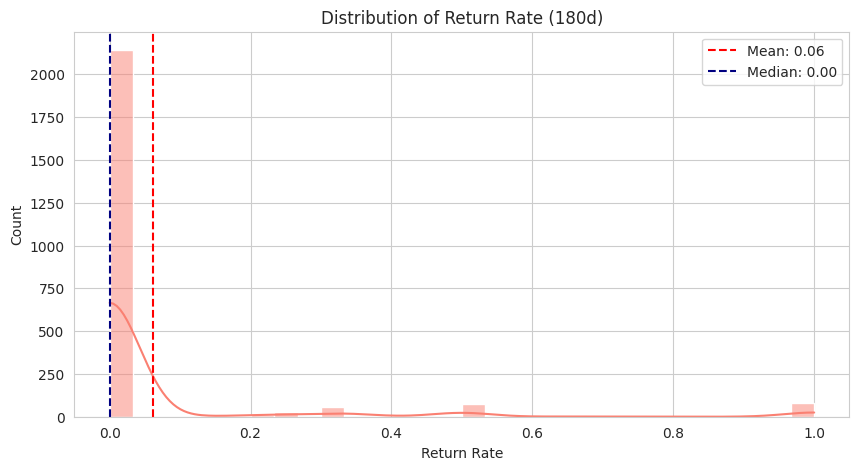

In [121]:
# SECTION 6: Return / Refund Behaviour
# 1. Distribution of return_rate_180d
plt.figure(figsize=(10,5))
sns.histplot(rfm_snapshot['return_rate_180d'], bins=30, kde=True, color='salmon')
plt.axvline(rfm_snapshot['return_rate_180d'].mean(), color='red', linestyle='--',
            label=f"Mean: {rfm_snapshot['return_rate_180d'].mean():.2f}")
plt.axvline(rfm_snapshot['return_rate_180d'].median(), color='navy', linestyle='--',
            label=f"Median: {rfm_snapshot['return_rate_180d'].median():.2f}")
plt.title("Distribution of Return Rate (180d)")
plt.xlabel("Return Rate")
plt.legend()
plt.show()

  return_bucket      mean  count  churn_rate_pct
0            0%  0.471522   2142            47.2
1         1-25%  0.086957     46             8.7
2        26-50%  0.390625    128            39.1
3        51-75%  0.400000      5            40.0
4       76-100%  0.772152     79            77.2


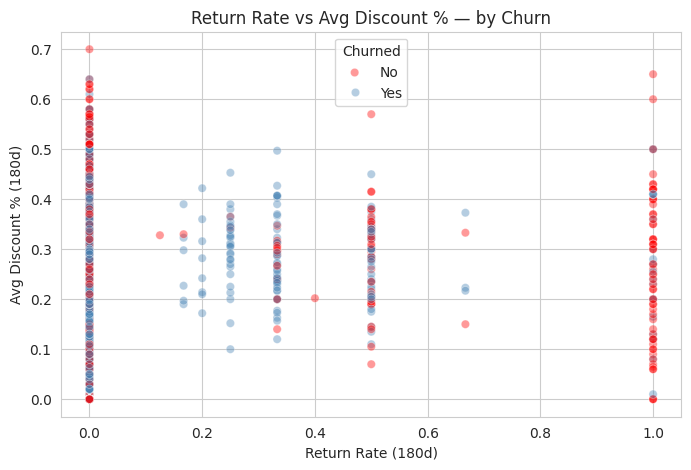

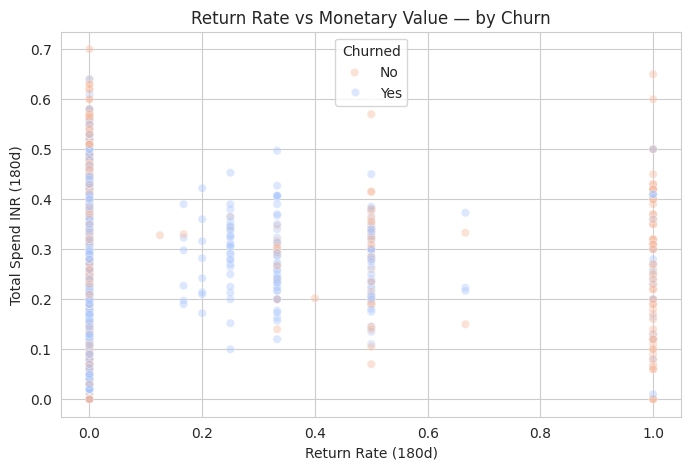

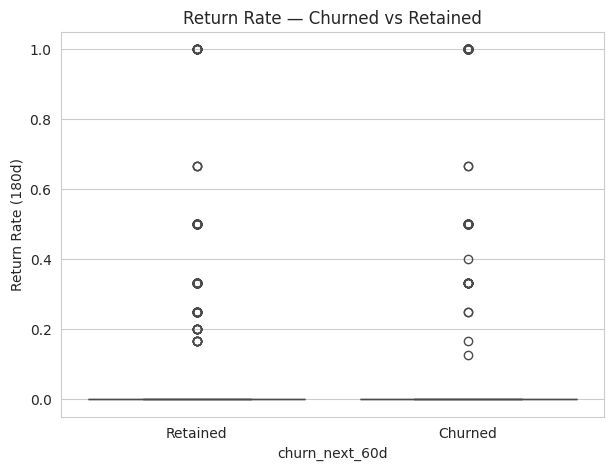

                 count   mean    std  min  25%  50%  75%  max
churn_next_60d                                               
0               1273.0  0.048  0.159  0.0  0.0  0.0  0.0  1.0
1               1127.0  0.076  0.243  0.0  0.0  0.0  0.0  1.0


In [122]:
#Churn rate by return rate bucket
rfm_snapshot['return_bucket'] = pd.cut(rfm_snapshot['return_rate_180d'],
    bins=[-0.01, 0.0, 0.25, 0.5, 0.75, 1.01],
    labels=['0%', '1-25%', '26-50%', '51-75%', '76-100%'])
return_churn = rfm_snapshot.groupby('return_bucket', observed=True)['churn_next_60d'].agg(['mean','count']).reset_index()
return_churn['churn_rate_pct'] = (return_churn['mean'] * 100).round(1)
print(return_churn)
#Return rate vs Discount
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm_snapshot, x='return_rate_180d', y='avg_discount_pct_180d',
                hue='churn_next_60d', alpha=0.4, palette={0:'steelblue', 1:'red'})
plt.title("Return Rate vs Avg Discount % — by Churn")
plt.xlabel("Return Rate (180d)")
plt.ylabel("Avg Discount % (180d)")
plt.legend(title='Churned', labels=['No','Yes'])
plt.show()
#Return rate vs Monetary value
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm_snapshot, x='return_rate_180d', y='avg_discount_pct_180d',
                hue='churn_next_60d', alpha=0.4, palette='coolwarm')
plt.title("Return Rate vs Monetary Value — by Churn")
plt.xlabel("Return Rate (180d)")
plt.ylabel("Total Spend INR (180d)")
plt.legend(title='Churned', labels=['No','Yes'])
plt.show()
#Boxplot-return rate churners vs non-churners

plt.figure(figsize=(7,5))
sns.boxplot(data=rfm_snapshot, x='churn_next_60d', y='return_rate_180d',
            palette=['steelblue', 'salmon'])
plt.xticks([0,1], ['Retained','Churned'])
plt.title("Return Rate — Churned vs Retained")
plt.ylabel("Return Rate (180d)")
plt.show()
print(rfm_snapshot.groupby('churn_next_60d')['return_rate_180d'].describe().round(3))

### Return / Refund Behaviour — Observations

- Majority of customers have a **0% return rate** in 180 days.
- Distribution is **heavily right-skewed** with a small segment returning 50–100% of orders.
- Churned customers have a higher mean return rate (0.076) vs retained (0.048)
- No discount-abuse pattern — high returners are spread evenly across all discount levels.
- High monetary spenders and low spenders **both appear across all return rate bands** .

In [123]:
#SECTION 7: Web / App Activity

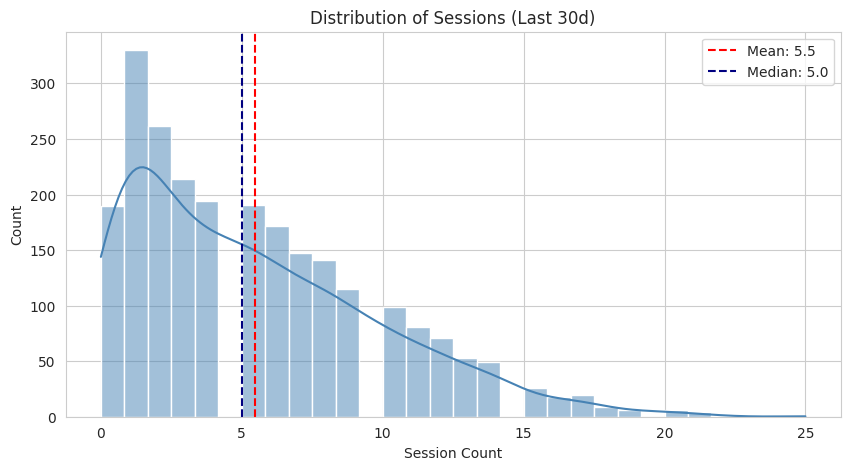

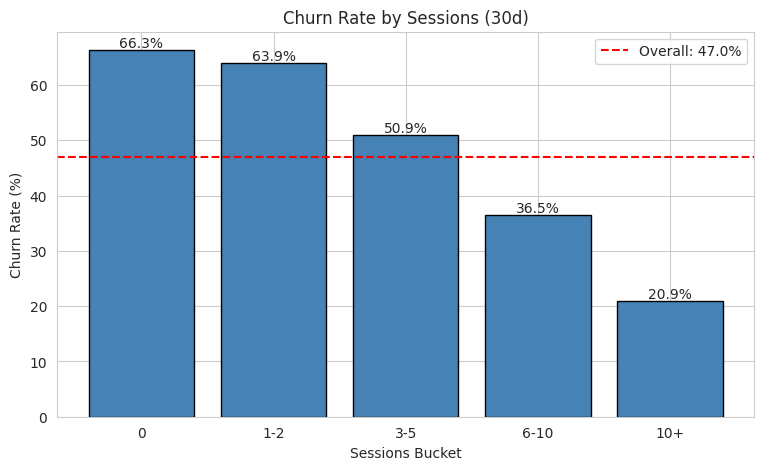

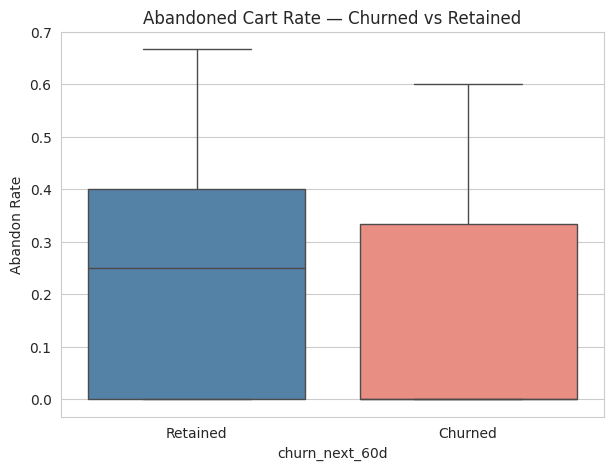

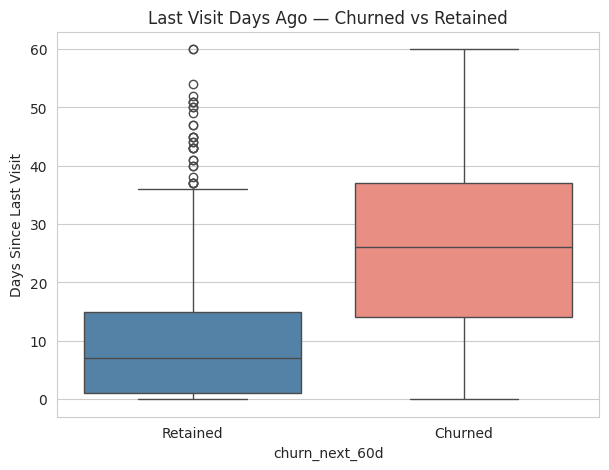

                 count   mean    std  min   25%   50%   75%   max
churn_next_60d                                                   
0               1273.0   9.77  10.30  0.0   1.0   7.0  15.0  60.0
1               1127.0  26.55  16.42  0.0  14.0  26.0  37.0  60.0
                email_opens_30d  campaign_clicks_30d
churn_next_60d                                      
0                          2.95                 0.74
1                          2.30                 0.55


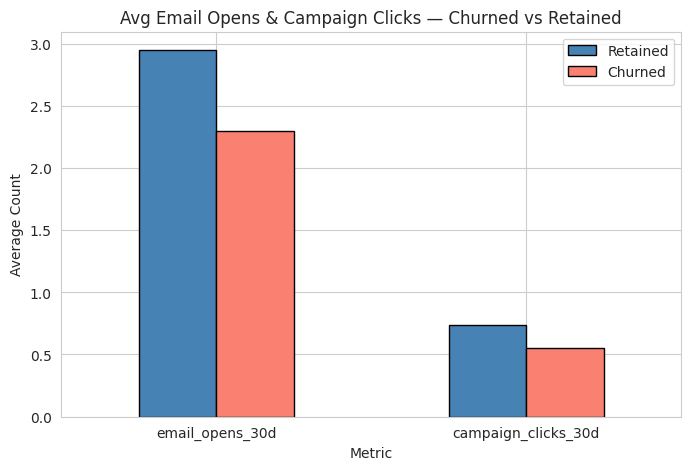

In [124]:
#Distribution of sessions_30d
plt.figure(figsize=(10,5))
sns.histplot(rfm_snapshot['sessions_30d'], bins=30, kde=True, color='steelblue')
plt.axvline(rfm_snapshot['sessions_30d'].mean(), color='red', linestyle='--',
            label=f"Mean: {rfm_snapshot['sessions_30d'].mean():.1f}")
plt.axvline(rfm_snapshot['sessions_30d'].median(), color='navy', linestyle='--',
            label=f"Median: {rfm_snapshot['sessions_30d'].median():.1f}")
plt.title("Distribution of Sessions (Last 30d)")
plt.xlabel("Session Count")
plt.legend()
plt.show()

#Churn rate by sessions bucket
rfm_snapshot['sessions_bucket'] = pd.cut(rfm_snapshot['sessions_30d'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['0', '1-2', '3-5', '6-10', '10+'])

sessions_churn = rfm_snapshot.groupby('sessions_bucket', observed=True)['churn_next_60d'].agg(['mean','count']).reset_index()
sessions_churn['churn_rate_pct'] = (sessions_churn['mean'] * 100).round(1)

plt.figure(figsize=(9,5))
bars = plt.bar(sessions_churn['sessions_bucket'], sessions_churn['churn_rate_pct'],
               color='steelblue', edgecolor='black')
overall = rfm_snapshot['churn_next_60d'].mean() * 100
plt.axhline(overall, linestyle='--', color='red', label=f'Overall: {overall:.1f}%')
for bar, val in zip(bars, sessions_churn['churn_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val}%', ha='center')
plt.title("Churn Rate by Sessions (30d)")
plt.xlabel("Sessions Bucket")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

# 3. Abandoned cart rate vs churn
rfm_snapshot['abandon_rate'] = rfm_snapshot['abandoned_carts_30d'] / (rfm_snapshot['cart_adds_30d'] + 1)
plt.figure(figsize=(7,5))
sns.boxplot(data=rfm_snapshot, x='churn_next_60d', y='abandon_rate',
            palette=['steelblue','salmon'])
plt.xticks([0,1], ['Retained','Churned'])
plt.title("Abandoned Cart Rate — Churned vs Retained")
plt.ylabel("Abandon Rate")
plt.show()
# 4. Last visit days ago vs churn
plt.figure(figsize=(7,5))
sns.boxplot(data=rfm_snapshot, x='churn_next_60d', y='last_visit_days_ago',
            palette=['steelblue','salmon'])
plt.xticks([0,1], ['Retained','Churned'])
plt.title("Last Visit Days Ago — Churned vs Retained")
plt.ylabel("Days Since Last Visit")
plt.show()
print(rfm_snapshot.groupby('churn_next_60d')['last_visit_days_ago'].describe().round(2))
#Email engagement vs churn
email_churn = rfm_snapshot.groupby('churn_next_60d')[['email_opens_30d','campaign_clicks_30d']].mean().round(2)
print(email_churn)
email_churn.T.plot(kind='bar', figsize=(8,5), color=['steelblue','salmon'], edgecolor='black')
plt.title("Avg Email Opens & Campaign Clicks — Churned vs Retained")
plt.xlabel("Metric")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.legend(['Retained','Churned'])
plt.show()

### Web / App Activity — Observations

- **Sessions are right-skewed**,most customers have 5 or fewer sessions in the last 30 days.
- 0 sessions = 66.3% churn 10+ sessions = 20.9% churn ,inactivity is a strong churn signal.
- **Retained customers have slightly higher abandon rates** ,churners likely stop browsing altogether.
- **Last visit days ago is the strongest separator** ,retained median 7 days vs churned median 26 days.
- **Churned customers open fewer emails** (2.30 vs 2.95) and click less (0.55 vs 0.74) .
- Overall, digital inactivity across sessions, visits, and emails reliably precedes churn.

In [125]:
#section 8 campaign or intervention history

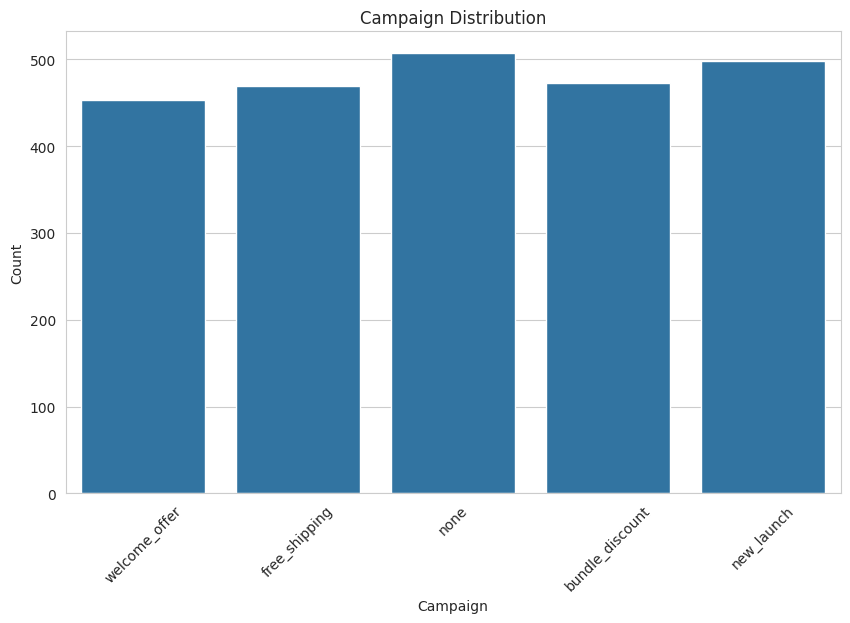

In [126]:
#Campaign Distribution
sns.countplot(data=intervention_history,x='last_campaign_received')
plt.xticks(rotation=45)
plt.title('Campaign Distribution')
plt.xlabel('Campaign')
plt.ylabel('Count')
plt.show()

### Campaign Distribution — Analysis

All 5 campaign types were delivered to roughly equal customer counts (~453–507).

- none: ~507 (highest — no campaign sent)
- new_launch: ~500
- bundle_discount: ~474
- free_shipping: ~470
- welcome_offer: ~453

* All campaign types were distributed to a similar number of customers (around 450–507 each), indicating that campaigns were broadly distributed rather than highly targeted to specific customer groups.

* Campaign effectiveness varied despite similar reach.

* For example, **new_launch** had the highest churn rate (51%), while **welcome_offer** had one of the lowest churn rates (45.3%), suggesting that campaign relevance is more important than campaign reach.

In [127]:
#Section 9: Churn Distribution

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


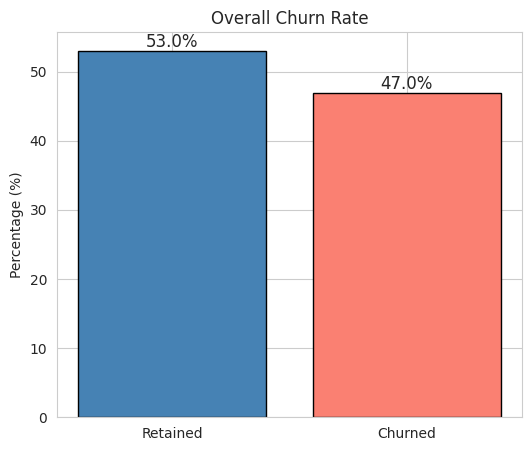

        split      mean  count  churn_rate_pct
0        test  0.500000    336            50.0
1       train  0.469907   1728            47.0
2  validation  0.437500    336            43.8


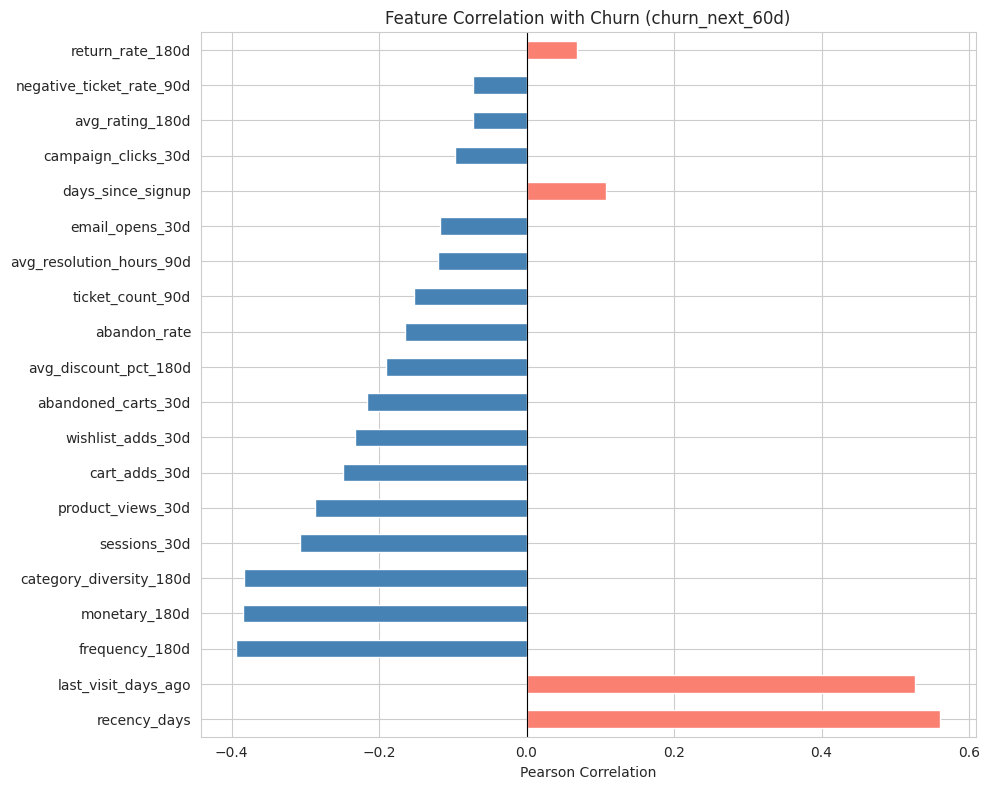


 Churner vs Non-churner mean comparison table
                          Retained  Churned  Difference          Direction
recency_days                 45.07   135.16       90.09   ↑ Churned Higher
days_since_signup           309.91   348.67       38.76   ↑ Churned Higher
last_visit_days_ago           9.77    26.55       16.78   ↑ Churned Higher
return_rate_180d              0.05     0.08        0.03   ↑ Churned Higher
negative_ticket_rate_90d      0.16     0.11       -0.05  ↓ Retained Higher
avg_discount_pct_180d         0.27     0.22       -0.05  ↓ Retained Higher
abandon_rate                  0.22     0.15       -0.07  ↓ Retained Higher
avg_rating_180d               3.91     3.78       -0.13  ↓ Retained Higher
ticket_count_90d              0.30     0.15       -0.15  ↓ Retained Higher
campaign_clicks_30d           0.74     0.55       -0.19  ↓ Retained Higher
abandoned_carts_30d           0.85     0.47       -0.38  ↓ Retained Higher
wishlist_adds_30d             1.06     0.59       -0.

In [128]:
# 1. Overall churn rate
churn_rate = rfm_snapshot['churn_next_60d'].value_counts(normalize=True) * 100
print(churn_rate)
plt.figure(figsize=(6,5))
bars = plt.bar(['Retained','Churned'], churn_rate.sort_index(),
               color=['steelblue','salmon'], edgecolor='black')
for bar, val in zip(bars, churn_rate.sort_index()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12)
plt.title("Overall Churn Rate")
plt.ylabel("Percentage (%)")
plt.show()
# 2. Churn rate by train/val/test split
split_churn = rfm_snapshot.groupby('split')['churn_next_60d'].agg(['mean','count']).reset_index()
split_churn['churn_rate_pct'] = (split_churn['mean'] * 100).round(1)
print(split_churn)
# 3. Correlation of all numeric features vs churn
numeric_cols = rfm_snapshot.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'churn_next_60d']

corr = rfm_snapshot[numeric_cols + ['churn_next_60d']].corr()['churn_next_60d'].drop('churn_next_60d')
corr_sorted = corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10,8))
corr[corr_sorted.index].plot(kind='barh', color=corr[corr_sorted.index].apply(
    lambda x: 'salmon' if x > 0 else 'steelblue'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Churn (churn_next_60d)")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()
# 4. Churner vs Non-churner mean comparison table
print('\n Churner vs Non-churner mean comparison table')
summary = rfm_snapshot.groupby('churn_next_60d')[numeric_cols].mean().round(2).T
summary.columns = ['Retained','Churned']
summary['Difference'] = (summary['Churned'] - summary['Retained']).round(2)
summary['Direction'] = summary['Difference'].apply(lambda x: '↑ Churned Higher' if x > 0 else '↓ Retained Higher')
print(summary.sort_values('Difference', ascending=False))

### Churn Distribution — Observations

- **Overall churn rate is 47%** — nearly half the customer base is at risk, making this a critical business problem.
- **Split churn rates are consistent** — train (47.0%), validation (43.8%), test (50.0%) — no major imbalance across splits.
- **Recency_days (0.55) and last_visit_days_ago (0.52) are the strongest positive correlates** — the longer a customer has been inactive, the more likely they are to churn.
- **Frequency_180d (-0.42), monetary_180d (-0.40), and sessions_30d (-0.37) are the strongest negative correlates** — customers who buy more, spend more, and browse more are far less likely to churn.
- **Churned customers show dramatically lower engagement** — avg sessions 4.02 vs 6.73, product views 16.97 vs 28.38, and monetary spend ₹756 vs ₹1,554 for retained.
- **Recency gap is the starkest difference** — churned customers last ordered 135 days ago on average vs 45 days for retained — a 3x difference and the single most actionable churn signal.

# Churn-risk Hypothesis
### **Hypothesis 1:** Customers who have not ordered recently are at the highest risk of churning

**Supporting Evidence:**
- ***Churn Rate by Recency*** — customers inactive for 180+ days churn at the highest rate
- ***Feature correlation bar chart*** — recency_days (0.55) is the strongest positive correlator with churn
- ***Churner vs Non-churner mean table*** — churned customers last ordered 135 days ago vs 45 days for retained (3x gap)

**Observation:** Recency is the single strongest predictor of churn in the entire dataset. The longer a customer has been inactive, the more certain they are to churn.

**Business Insight:** Customers inactive for 90+ days should trigger an automatic re-engagement campaign before they are permanently lost.

### **Hypothesis 2:** One-Time Buyers Are Most Likely to Churn

**Supporting Evidence:**
- ***Order Count vs Churn Summary table*** — 100% churn for 1-order customers
- ***Churn Rate by Order Frequency chart*** — drops sharply from 100% → 49.5% → 8.8%

**Observation:** No customer who placed only one order was retained. Churn drops dramatically with each additional order placed.

**Business Insight:** A post-first-purchase campaign within 7 days is the highest ROI retention intervention available.

### **Hypothesis 3:** Digitally inactive customers are significantly more likely to churn

**Supporting Evidence:**
- ***Churn Rate by Sessions chart*** —

      0 sessions = 66.3%
      churn vs 10+ sessions = 20.9%
- ***Last Visit Days Ago boxplot***— retained median 7 days vs churned median 26 days

**Observation:** Digital inactivity across sessions, last visit, and email opens consistently precedes churn across all web channels.

**Business Insight:** A triggered re-engagement push notification or promotional campaigns when a customer hasn't visited in 14+ days could intercept churners before the window closes.

### **Hypothesis 4:** Low monetary spend and low purchase frequency strongly predict churn

**Supporting Evidence:**
- ***Churn Rate by Monetary Spend*** — low spend customers churn at 75.7%
- ***Churn Rate by Purchase Frequency*** — zero-frequency customers churn at 91.4%
- ***Mean comparison table*** — churned customers spent ₹756 vs ₹1,554 for retained

**Observation:** Customers who spend very little are substantially more likely to churn than customers generating higher revenue. Higher spenders appear more invested in the brand and therefore exhibit stronger loyalty.

**Business Insight:** Early loyalty incentives such as bundle discounts or free shipping should target low-spend customers before they disengage.

### **Hypothesis 5:** Customers who purchase from only one category are at very high churn risk

**Supporting Evidence:**
- ***Churn Rate by Category Diversity*** — customers with 0 purchases churn at 91.4%,
  single-category customers churn at 50.5%, dropping to 10.0% for 4+ categories
- ***Category Diversity Distribution*** — over 1,220 customers (50%+) purchase
  from only one category, making this the largest and most at-risk segment

**Observation:** Customers with 0 purchases in 180 days churn at 91.4%. Even moving from 1 category to 2 categories cuts churn from 50.5% to 31.5% — a near 40% drop

**Business Implication:** Cross-sell campaigns nudging single-category customers to explore related categories could significantly reduce churn in this large segment.

### **Hypothesis 6:** Poor Product Experience Increases Churn

**Supporting Evidence:**
- ***Average Rating vs Churn (Cell 73)*** — Excellent-rated customers churn least at 38.8%
- ***Mean Comparison Table (Cell 102)*** — churned customers average rating 3.78 vs retained 3.91

**Observation:** No strict linear trend exists between ratings and churn, but customers with
Excellent ratings (4–5) show the best retention at 38.8% — clearly below the 47% overall rate.

**Business Insight:** Improving product quality and post-purchase experience to push customers into the excellent rating band could directly reduce churn risk.





